# **Initial EDA and Data Understanding**

## **1. Import Python Libraries**

In [ ]:
import marimo as mo
import pyspark 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

## **2. Initilaize Apache Spark Session**

In [ ]:
spark = SparkSession.builder.appName("Loan_Application_Classifier").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/13 21:20:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/13 21:20:30 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/13 21:20:30 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/13 21:20:30 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/04/13 21:20:30 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


## **3. Setup file paths**

In [ ]:
# Setup the base path
base_dir = os.path.abspath('/Users/ananddivakaran/Documents/Anand/MDS/loan_app')
print(f'Base Data Directory:{base_dir}')
input_path = f"file://{os.path.join(base_dir, 'data/raw/loan_data.csv')}"
print(f'Input file: {input_path}')
output_path = os.path.join(base_dir, "/data/interim/loan_data_interim.csv")
print(f'Output file:{output_path}')

Base Data Directory:/Users/ananddivakaran/Documents/Anand/MDS/loan_app
Input file: file:///Users/ananddivakaran/Documents/Anand/MDS/loan_app/data/raw/loan_data.csv
Output file:/data/interim/loan_data_interim.csv


## **4. Load the dataset**

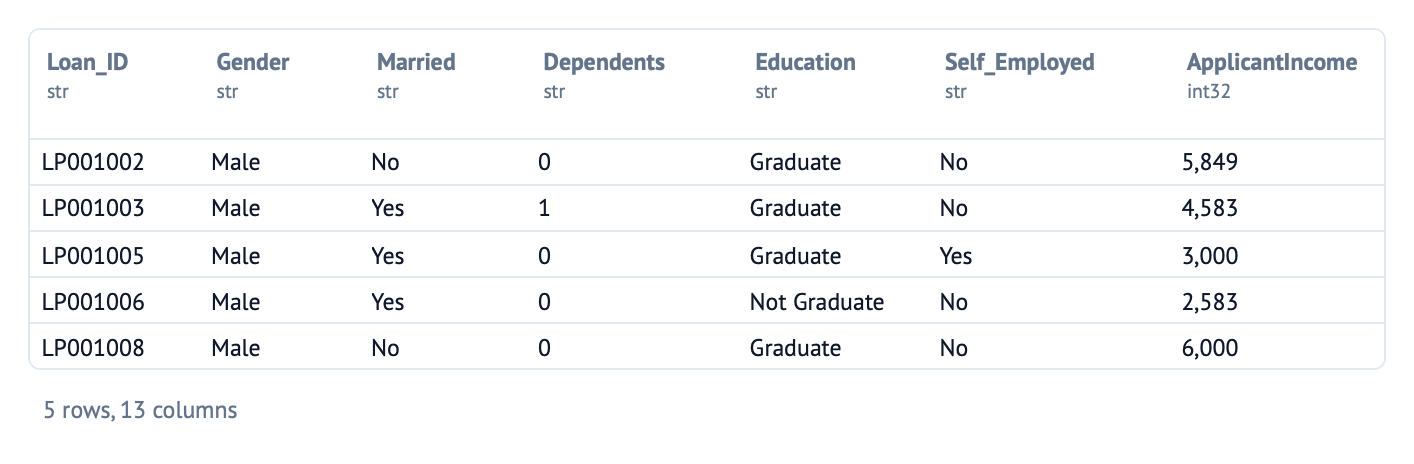

In [ ]:
# Read data
data = spark.read.csv(input_path, header=True, inferSchema=True)
# Converting the data to pandas dataframe for easy analysis
df = data.toPandas()
df.head(5)

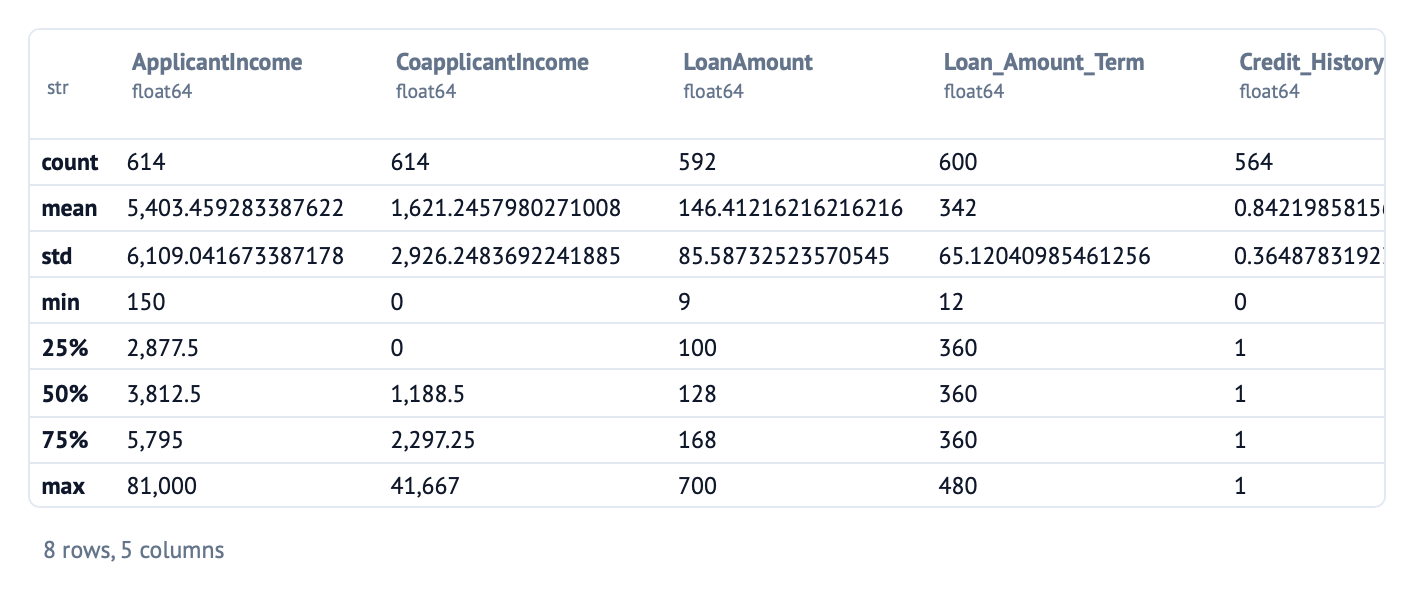

In [ ]:
df.describe()

In [ ]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The dataset has 614 rows and 13 columns


#### Columns in the dataset

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int32  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int32(1), str(8)
memory usage: 81.0 KB


## **5. Checking for Null Values**

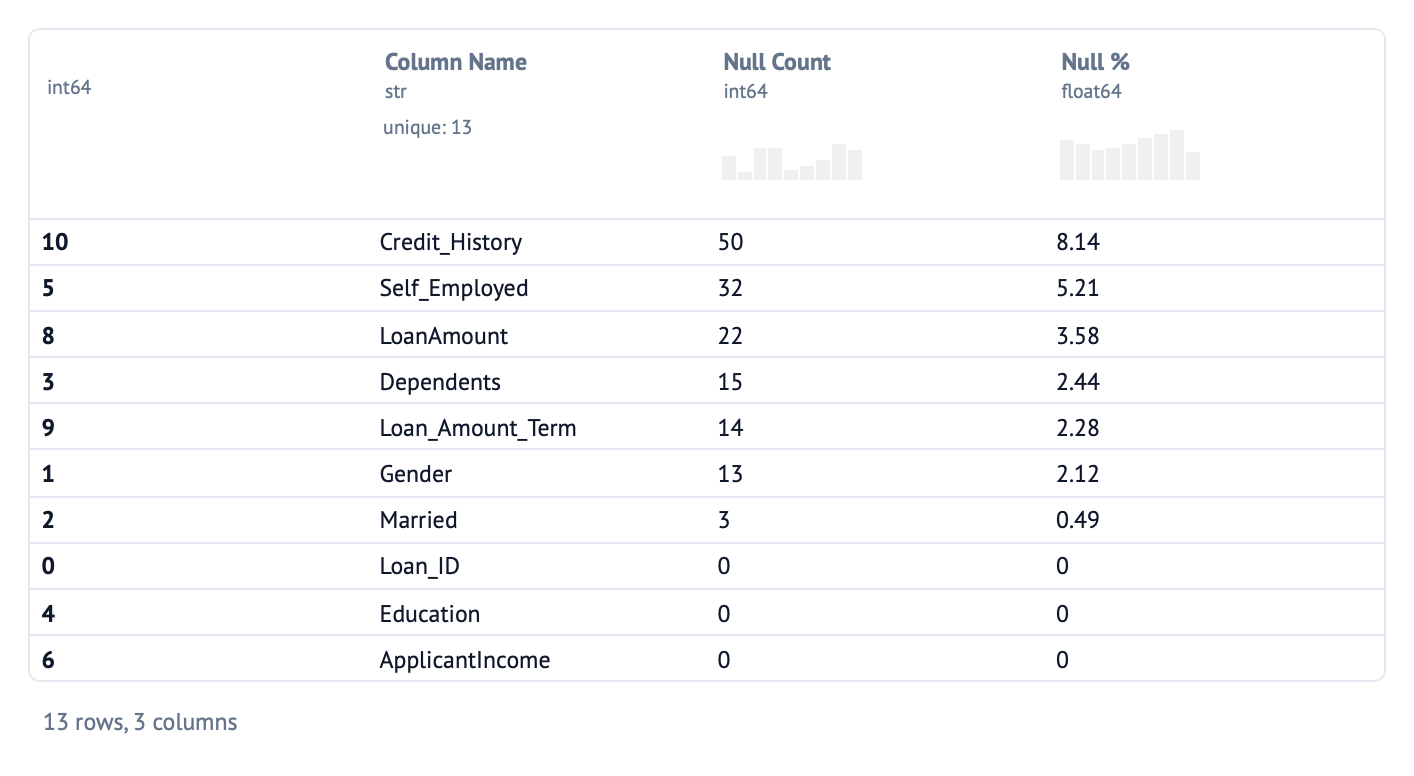

In [ ]:
def check_missing_data(df):
    report = []

    for col in df.columns:
        # 1. Count actual Nulls (NaN)
        null_count = df[col].isnull().sum()
        total_rows = len(df)
        null_percent = (null_count / total_rows) * 100

        report.append({
            'Column Name': col,
            'Null Count': null_count,
            'Null %': round(null_percent, 2)
        })

    return pd.DataFrame(report).sort_values('Null Count', ascending=False)

# Run the check
missing_report = check_missing_data(df)
pd.DataFrame(missing_report)

#### List of features with a NULL value

In [ ]:
null_df = df.isnull().sum().reset_index()
null_df.columns = ['Feature','Count']
null_df[null_df['Count'] >0].reset_index()['Feature'].to_list()

## **6. EDA and Analysis of features with a NULL value**

### **6.1 Inference for Gender Feature**

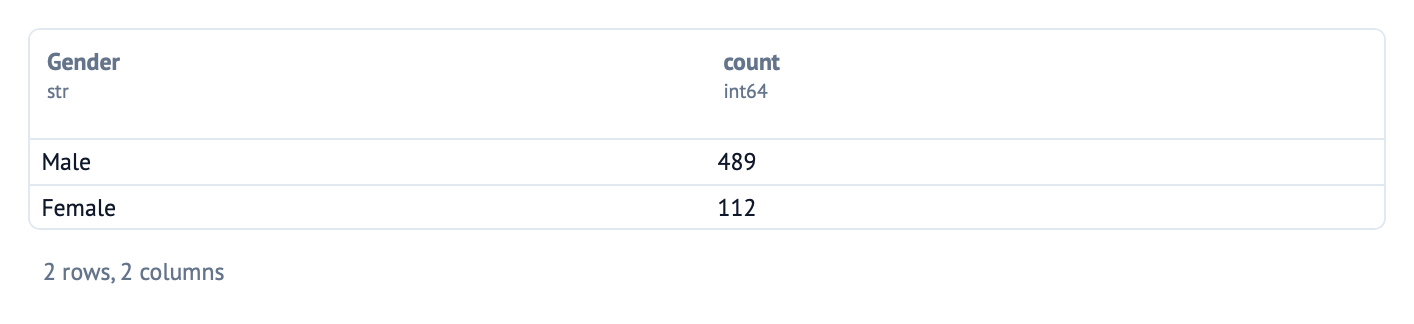

In [ ]:

df_gender_summ = df['Gender'].value_counts().reset_index()
df_gender_summ

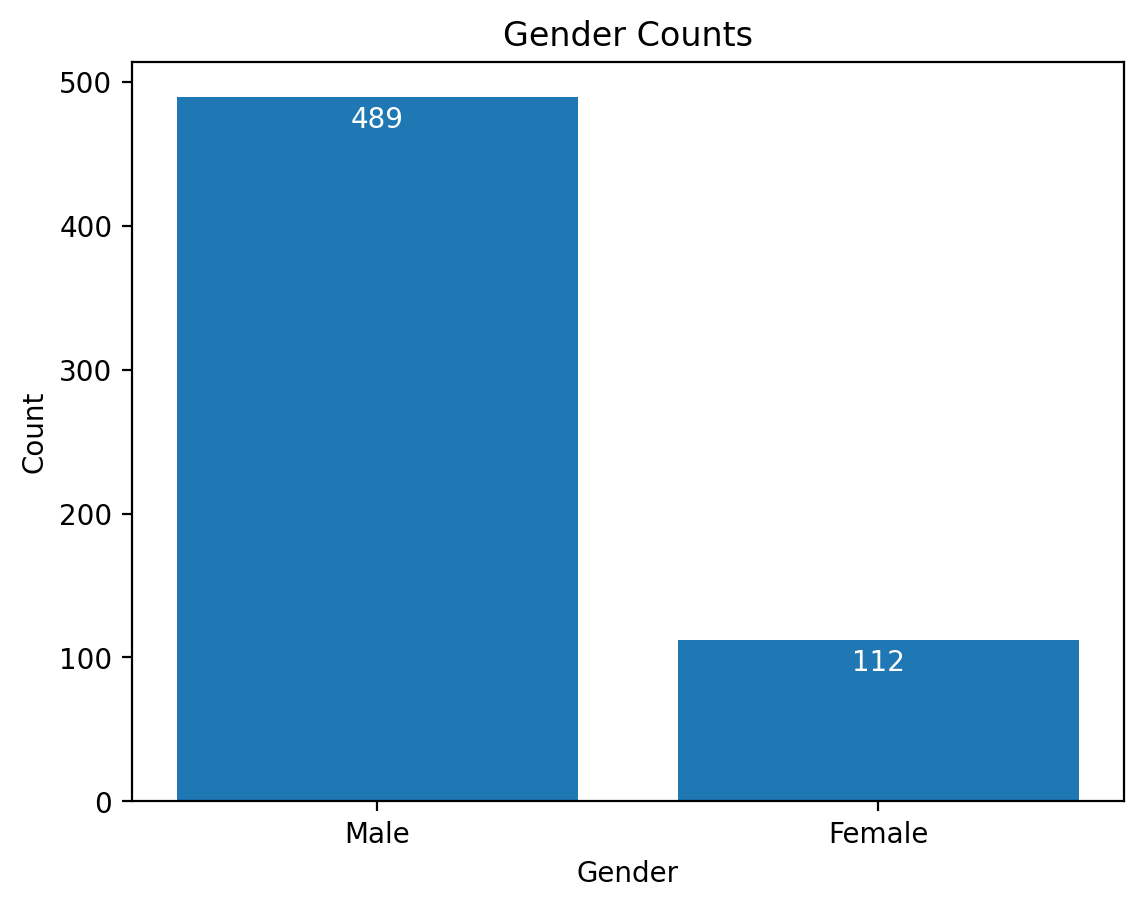

In [ ]:
bars_gender = plt.bar(df_gender_summ['Gender'], df_gender_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_g in bars_gender:
    height_g = bar_g.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_g.get_x() + bar_g.get_width() / 2, # X position (center of the bar)
        height_g - 25,                       # Y position (slightly above the bar height)
        f'{int(height_g)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white'        # Vertical alignment: bottom
    )

plt.title('Gender Counts')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### How many NULL values?

In [ ]:
print(f'Number of records with NULL values in the Gender Feature:{df.Gender.isna().sum()}')

Number of records with NULL values in the Gender Feature:13


Observations: <br>  Number of males in the dataset if more than the females.

Imputation Stratergy:<br> Use the mode to fill the null values (do this only after the split)

### **6.2 Inference for Marrried Feature**

In [ ]:
df_married_summ = df['Married'].value_counts().reset_index()

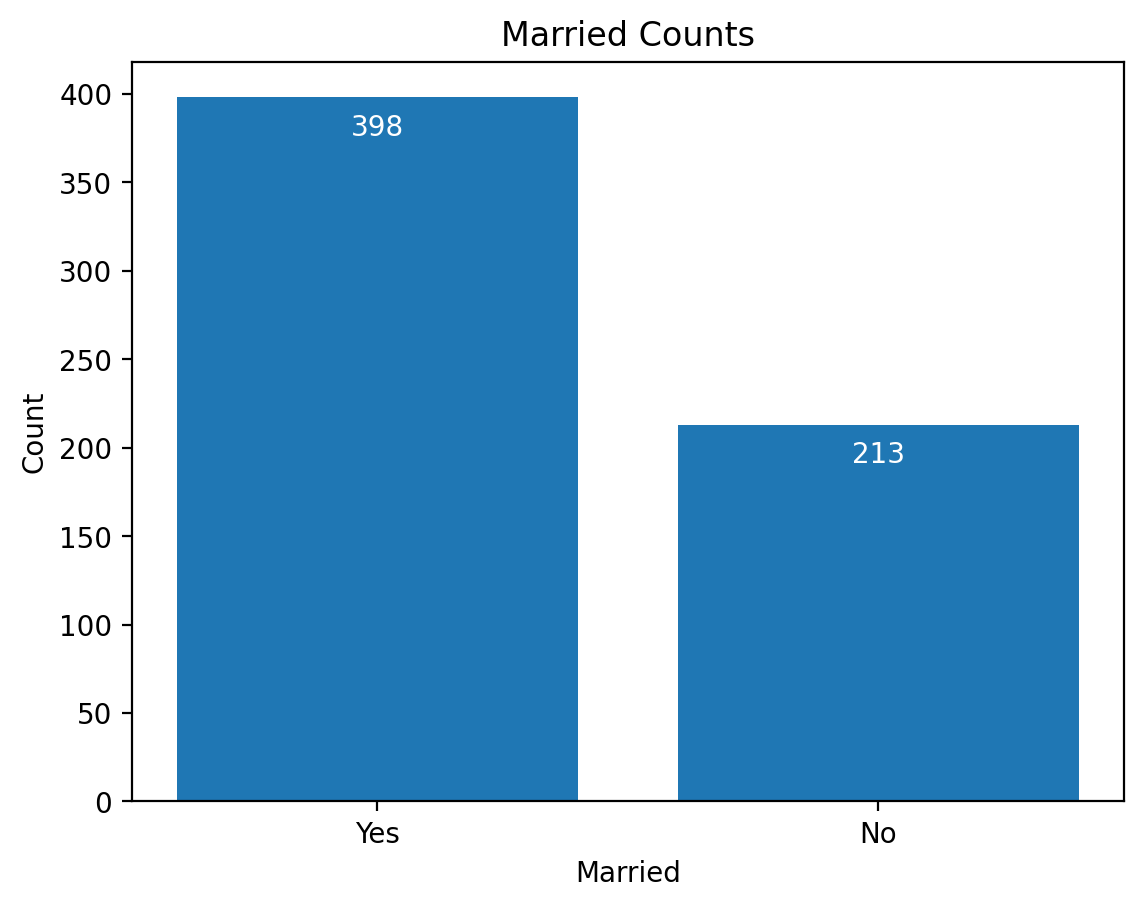

In [ ]:
bars_married = plt.bar(df_married_summ['Married'], df_married_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_m in bars_married:
    height_m = bar_m.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_m.get_x() + bar_m.get_width() / 2, # X position (center of the bar)
        height_m - 25,                       # Y position (slightly above the bar height)
        f'{int(height_m)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white'        # Vertical alignment: bottom
    )

plt.title('Married Counts')
plt.xlabel('Married')
plt.ylabel('Count')
plt.show()

#### How many NULL's?

In [ ]:
print(f'Number of records with NULL values in the Gender Feature:{df.Married.isna().sum()}')

Number of records with NULL values in the Gender Feature:3


Observations: <br> Number of Married people are more in the dataset than the unmarried.<br>
The number of people with a NULL value in the "Married" feature is 3. <br>

#### Check if the records with NULL married feature has dependents

In [ ]:
df_married_null = df[df['Married'].isnull()]

In [ ]:
married_w_dep = df_married_null['Dependents'].value_counts()
count_marrierd_w_dep = len(married_w_dep)
print(f"Number of people with no martial status but with dependets:{count_marrierd_w_dep}")

Number of people with no martial status but with dependets:0


As there are no dependents for these records we can set the married flag to 'No'

Imputation Stratergy:<br> If there are no dependents for the married people, set the married flag to "No"

In [ ]:
df['Married'] = df['Married'].fillna("No")
print(f'Number of records with NULL values in the Gender Feature:{df.Married.isna().sum()}')

Number of records with NULL values in the Gender Feature:0


### **6.3 Inference for Dependents**

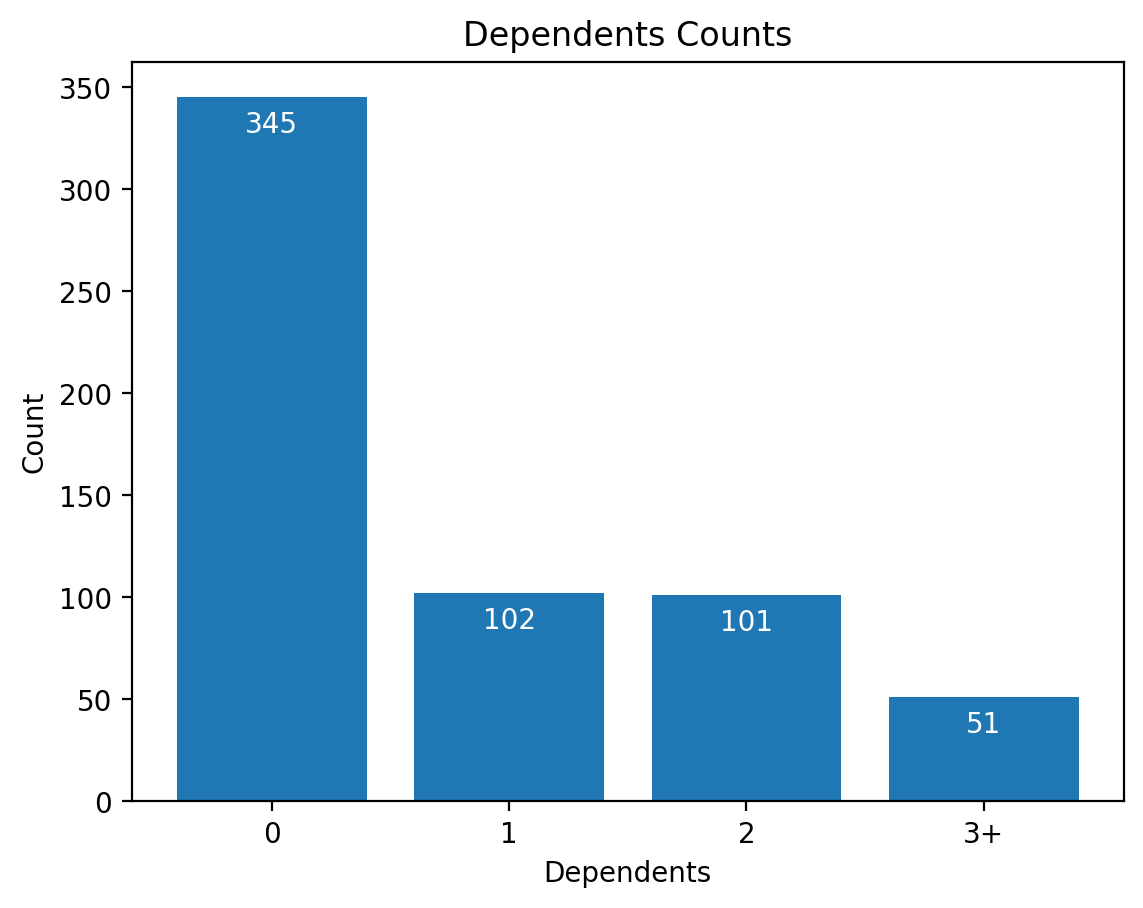

In [ ]:
df_dep_summ = df.Dependents.value_counts().reset_index()
bars = plt.bar(df_dep_summ['Dependents'], df_dep_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar in bars:
    height = bar.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar.get_x() + bar.get_width() / 2, # X position (center of the bar)
        height - 20,                       # Y position (slightly above the bar height)
        f'{int(height)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white'        # Vertical alignment: bottom
    )

plt.title('Dependents Counts')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.show()

#### How many NULLS?

In [ ]:
print(f'Number of records with NULL values in the Dependents Feature:{df.Dependents.isna().sum()}')

Number of records with NULL values in the Dependents Feature:15


Observations: <br>
There are only a small volume of data with null dependents - 15. We can set the dependents to zero for these 15 values as we could infer that not having a value means zero dependents.

### Updating the records with NULL dependent count

In [ ]:
df['Dependents'] = df['Dependents'].fillna(0)
print(f'Number of records with NULL values in the Dependents Feature:{df.Dependents.isna().sum()}')

Number of records with NULL values in the Dependents Feature:0


### **6.4 Inference for Self_Employed Feature**

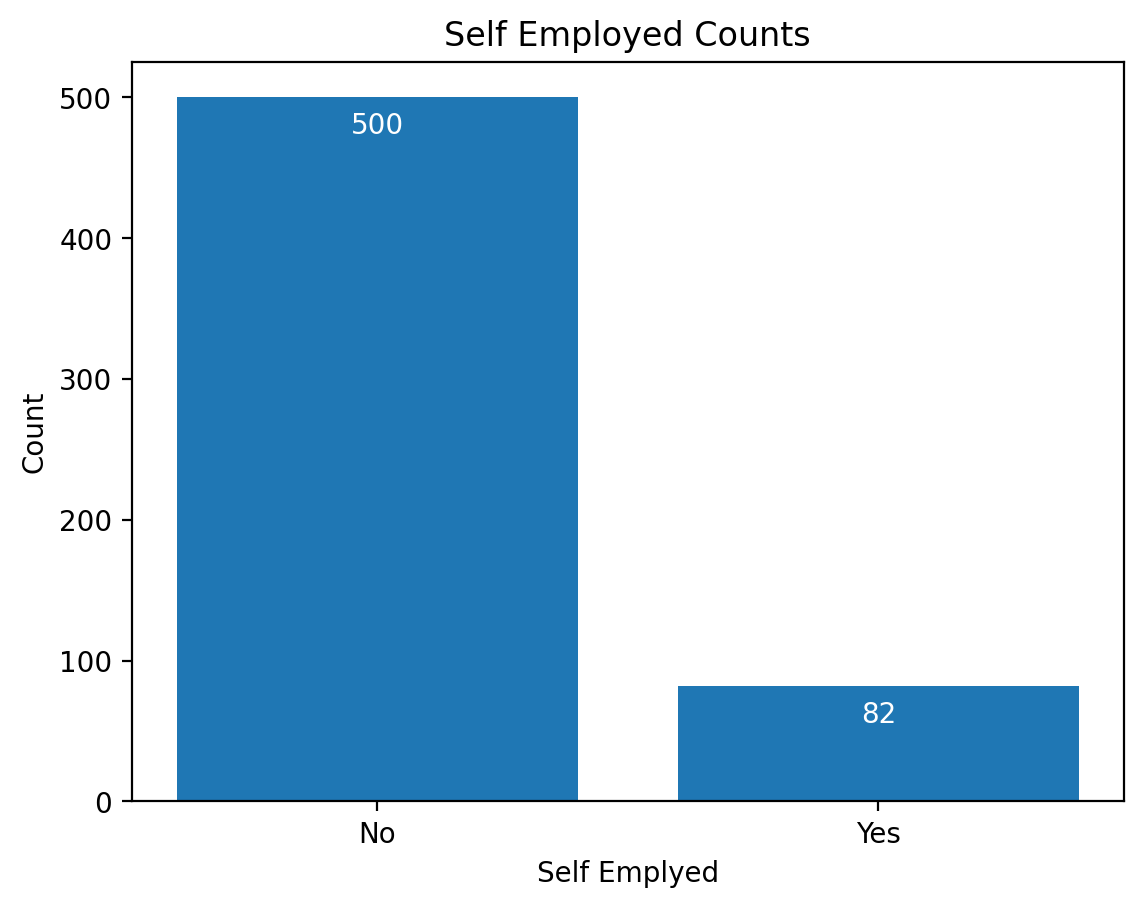

In [ ]:
df_selfe_summ = df.Self_Employed.value_counts().reset_index()
bars_se = plt.bar(df_selfe_summ['Self_Employed'], df_selfe_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_se in bars_se:
    height_se = bar_se.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_se.get_x() + bar_se.get_width() / 2, # X position (center of the bar)
        height_se - 30,                       # Y position (slightly above the bar height)
        f'{int(height_se)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white' )       # Vertical alignment: bottom

plt.title('Self Employed Counts')
plt.xlabel('Self Emplyed')
plt.ylabel('Count')
plt.show()

#### How many NULLS?

In [ ]:
print(f'Number of records with NULL values in the Self_Employed Feature:{df.Self_Employed.isna().sum()}')

Number of records with NULL values in the Self_Employed Feature:32


Observations:
There are only a small volume of data with null Self Employed - 32. We can set the the value of Self Employed to No for these 15 values as we could infer that not having a value not self employed.

In [ ]:
df['Self_Employed'] = df['Self_Employed'].fillna('No')
print(f'Number of records with NULL values in the Self_Employed Feature:{df.Self_Employed.isna().sum()}')

Number of records with NULL values in the Self_Employed Feature:0


### **6.5 Inference for Credit History Feature**

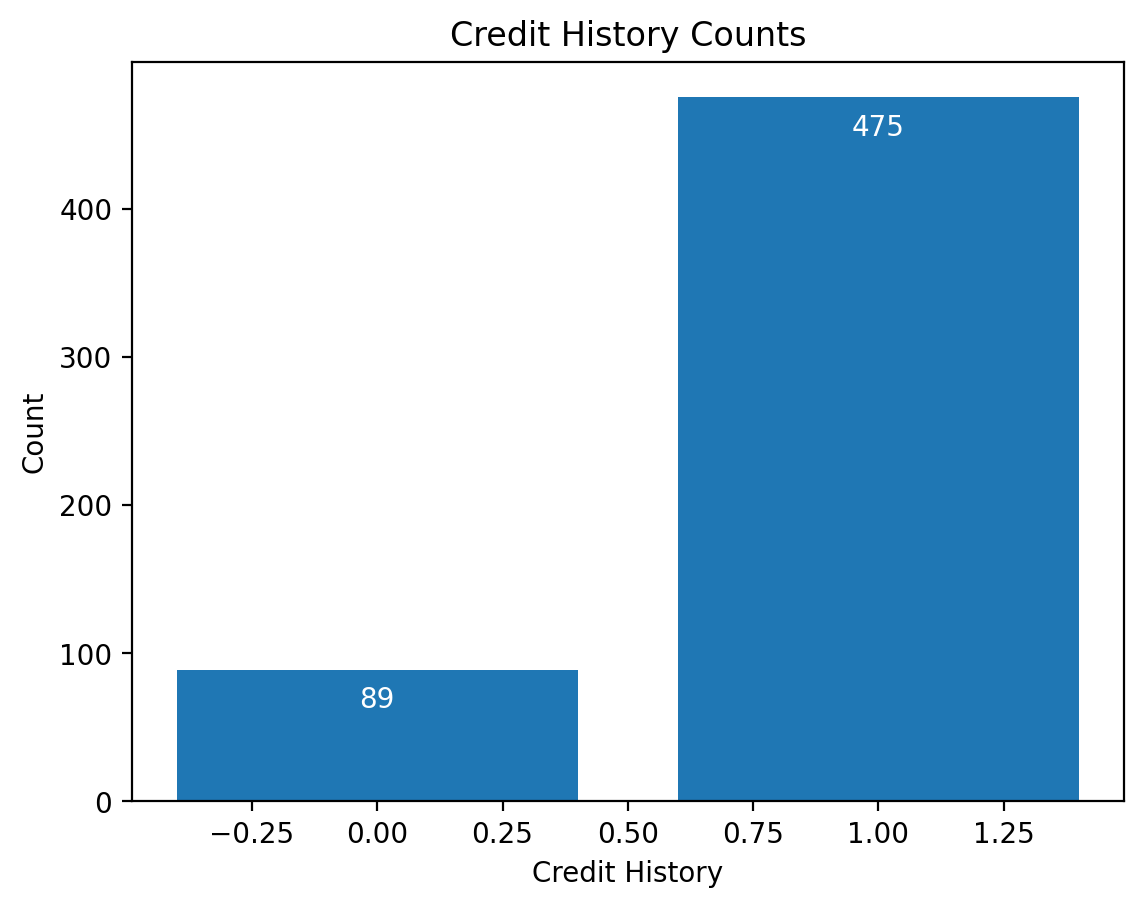

In [ ]:
df_ch_summ = df.Credit_History.value_counts().reset_index()
bars_ch = plt.bar(df_ch_summ['Credit_History'], df_ch_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_ch in bars_ch:
    height_ch = bar_ch.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_ch.get_x() + bar_se.get_width() / 2, # X position (center of the bar)
        height_ch - 30,                       # Y position (slightly above the bar height)
        f'{int(height_ch)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white' )       # Vertical alignment: bottom

plt.title('Credit History Counts')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.show()

#### How many NULLS?

In [ ]:
print(f'Number of records with NULL values in the Credit History Feature:{df.Credit_History.isna().sum()}')

Number of records with NULL values in the Credit History Feature:50


Observations: For the records with credit history as NULL - we can set the credit history as zero (No history) which is the same way.

In [ ]:
df['Credit_History'] = df['Credit_History'].fillna(0)

In [ ]:
print(f'Number of records with NULL values in the Credit History Feature:{df.Credit_History.isna().sum()}')

Number of records with NULL values in the Credit History Feature:0


### **6.6 Inference for Loan Amount Feature**

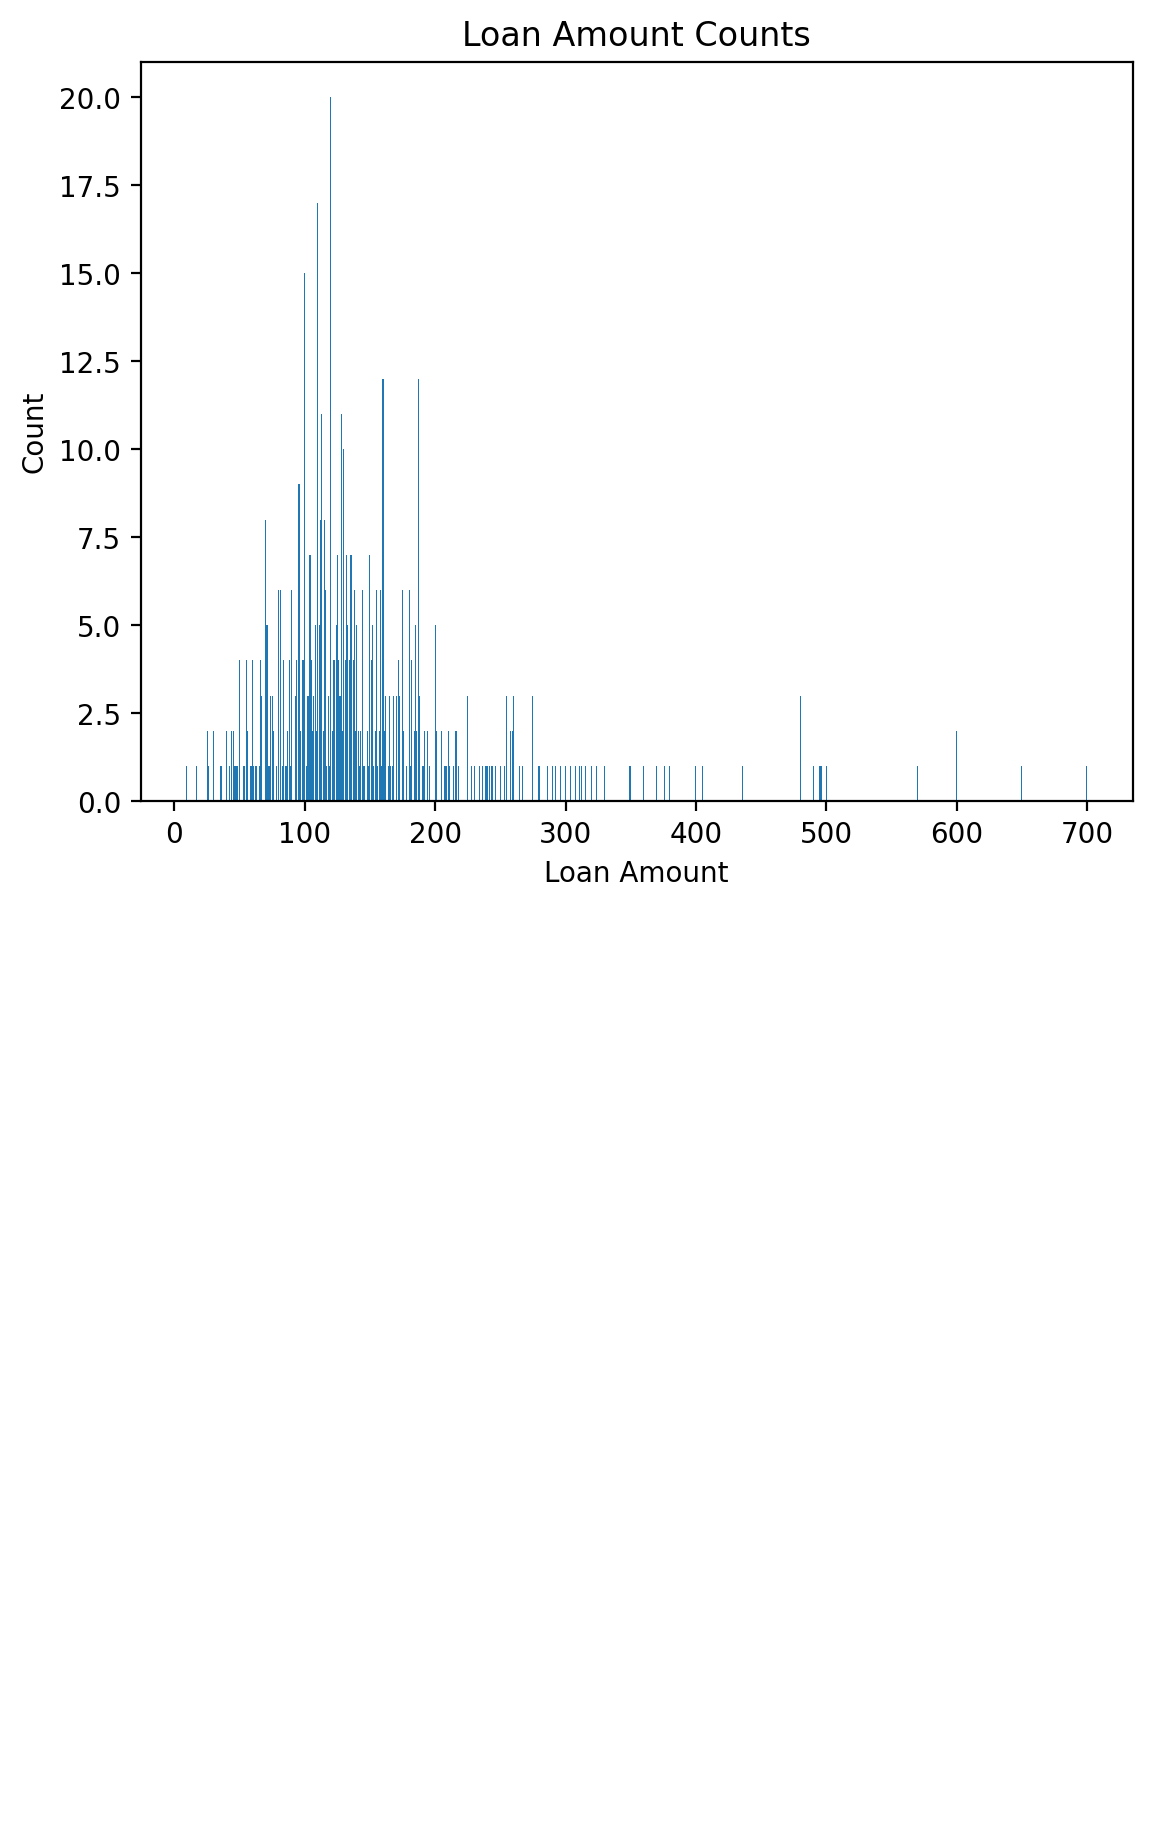

In [ ]:
df_la_summ = df.LoanAmount.value_counts().reset_index()
bars_la = plt.bar(df_la_summ['LoanAmount'], df_la_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_la in bars_la:
    height_la = bar_la.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_la.get_x() + bar_la.get_width() / 2, # X position (center of the bar)
        height_la - 30,                       # Y position (slightly above the bar height)
        f'{int(height_la)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white' )       # Vertical alignment: bottom

plt.title('Loan Amount Counts')
plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.show()

#### How many NULLS?

In [ ]:
print(f'Number of records with NULL values in the Loan Amount Feature:{df.LoanAmount.isna().sum()}')

Number of records with NULL values in the Loan Amount Feature:22


Observations: <br> As loan Amount is a mandatory field that needs to be entered by the applicant - these records can be thought of an invalid records as it doesnt give any analytical value to aid in the prediction.

In [ ]:
# Remove records from the dataframe with null loan amount
df_cleaned = df.dropna(subset=['LoanAmount'])

### **6.7 Inference for Loan Amount Term Feature**

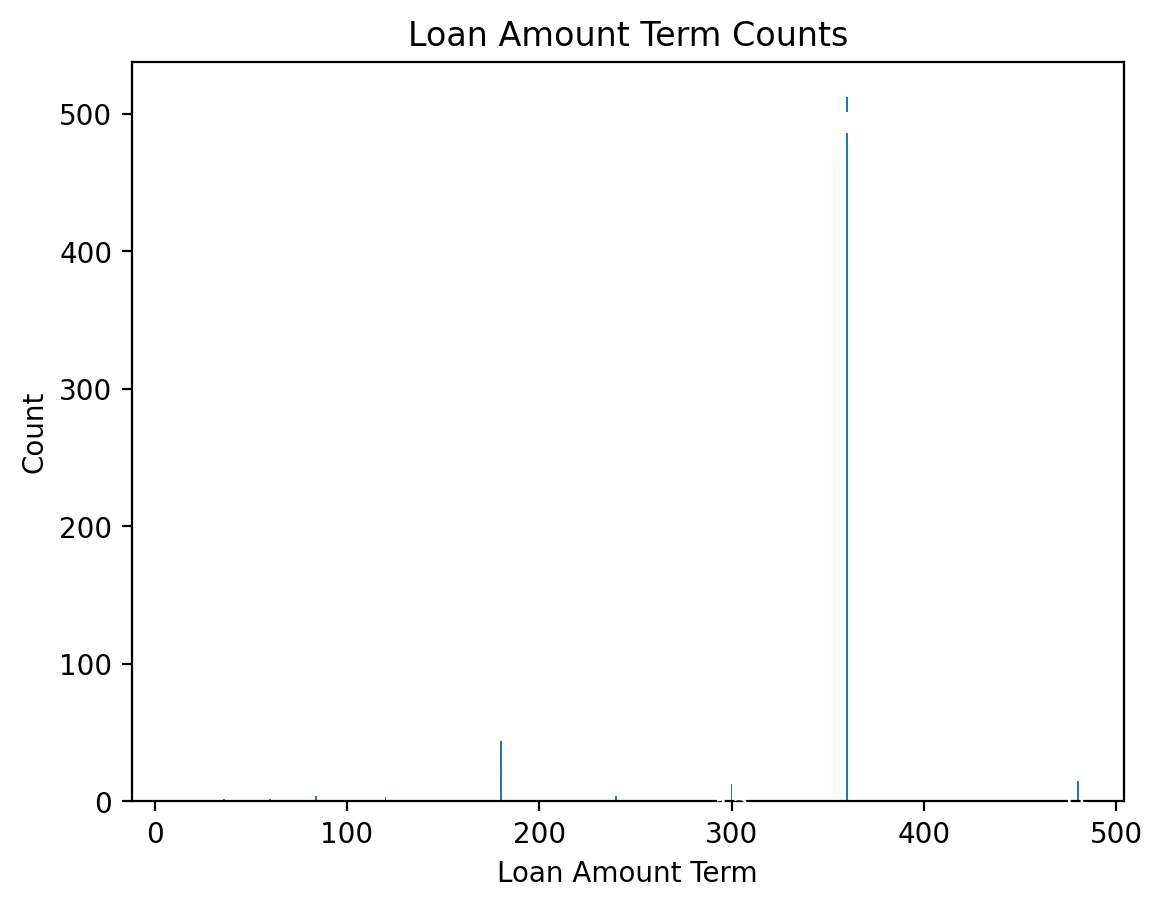

In [ ]:
df_lat_summ = df.Loan_Amount_Term.value_counts().reset_index()
bars_lat = plt.bar(df_lat_summ['Loan_Amount_Term'], df_lat_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_lat in bars_lat:
    height_lat = bar_lat.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_lat.get_x() + bar_lat.get_width() / 2, # X position (center of the bar)
        height_lat - 30,                       # Y position (slightly above the bar height)
        f'{int(height_lat)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white' )       # Vertical alignment: bottom

plt.title('Loan Amount Term Counts')
plt.xlabel('Loan Amount Term')
plt.ylabel('Count')
plt.show()

In [ ]:
print(f'Number of records with NULL values in the Loan Amount Term Feature:{df.Loan_Amount_Term.isna().sum()}')

Number of records with NULL values in the Loan Amount Term Feature:14


As these records has a loan Amount Vlaue, we can set the Loan Amount Term to the median loan Amount Term - This shoudl be done only after the split.

Disposition for NULL Values: <br>
1. Gender - Use the mode to fill the null values (do this only after the split)
2. Married - If the dependent count is 0, consider as un-married, else married. We can do this before the split.
3. Dependents - If the dependent count is null - the medain value.(do this only after the split)
4. Self_Employed - Set this to the median value. (do this after the split)
5. Loan Amount - Remove the records with loan amount zero as this person might not need a loan itself.(Possible data error)
6. Loan Amount Term - We can set the Loan Amount Term to the median loan Amount Term - (This should be done only after the split)
7. Credit History - Set as No-credit history. (Initilize this to no credit history as it is not reported by the credit beauroes.)

### How many NULLS after the excercise?

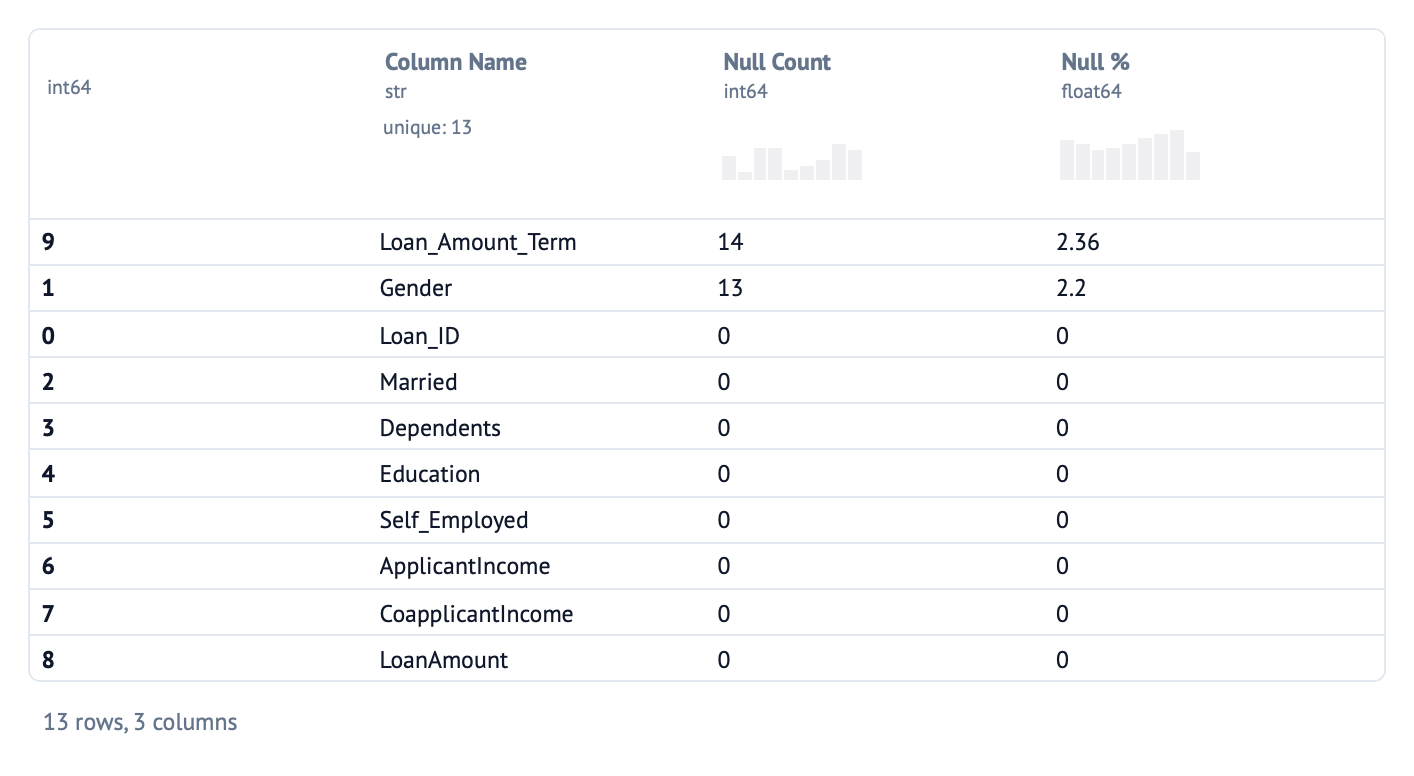

In [ ]:
# Run the check
missing_report_lat = check_missing_data(df_cleaned)
pd.DataFrame(missing_report_lat)

## **7. Check for Outliers in Numeric Fields and the Disposition**

### **7.1 Identify the numeric features**

In [ ]:
numeric_features = df.select_dtypes(include = np.number).columns.tolist()
numeric_features

### Define a function to check for outliers

In [ ]:
def detect_iqr(df_dat, feature):
    Q1 = df_dat[feature].quantile(0.25)
    Q3 = df_dat[feature].quantile(0.75)
    IQR = Q3-Q1
    Lower_Bound = Q1 - 1.5*IQR
    Upper_Bound = Q3 + 1.5*IQR
    Outliers = df_dat[(df_dat[feature] < Lower_Bound) | (df_dat[feature] > Upper_Bound)]
    print(f"\n--- IQR Method for {feature} ---")
    print(f"Lower Bound: {Lower_Bound:.2f}")
    print(f"Upper Bound: {Upper_Bound:.2f}")
    print(f"Number of Outliers Detected: {len(Outliers)}")
    return Lower_Bound, Upper_Bound,Outliers

### **7.1 Check for outliers in Applicant Income Feature**

#### Plot the data using a regular box plot to understand the outliers.

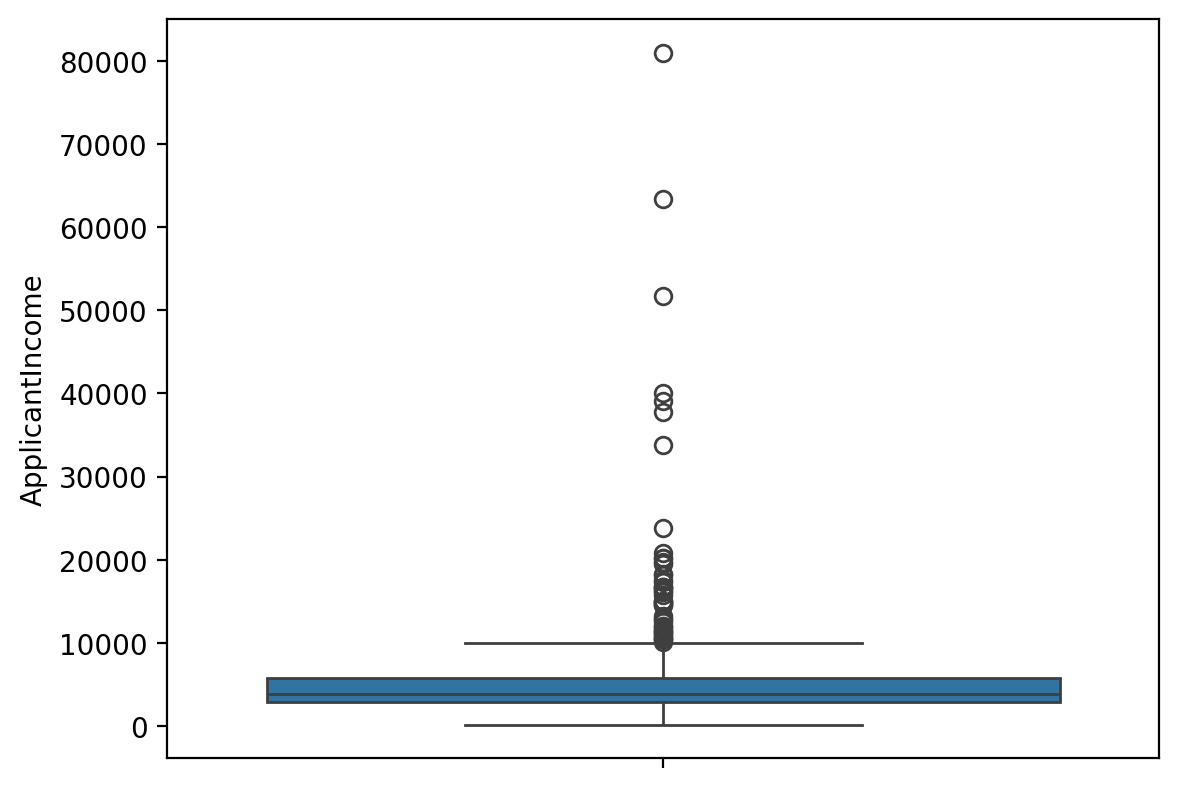

In [ ]:
sns.boxplot(data=df_cleaned, y = 'ApplicantIncome')
plt.show()

There are a few records with very high Income Amounts.

#### Understand the distribution of outliers using histplot.

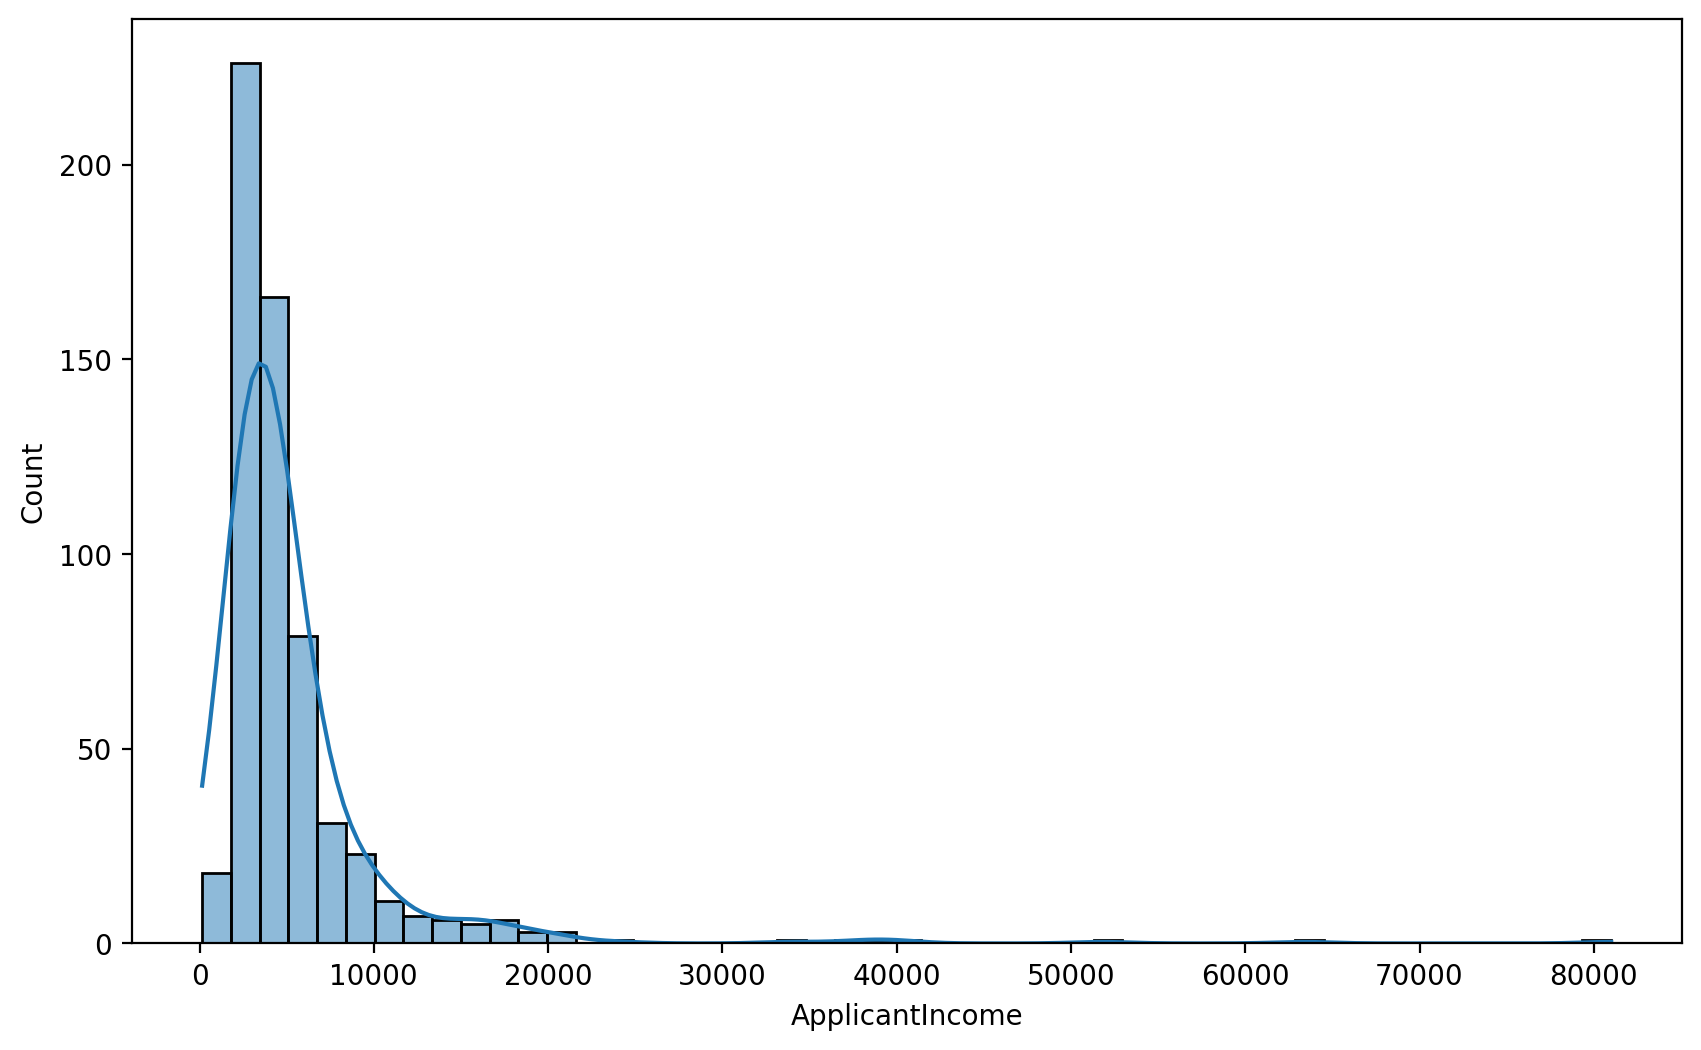

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df_cleaned.ApplicantIncome, kde=True)
plt.show()

#####Run the outlier Detection

In [ ]:
## Run the detection
lower_bound, upper_bound, iqr_outliers = detect_iqr(df_cleaned, 'ApplicantIncome')


--- IQR Method for ApplicantIncome ---
Lower Bound: -1413.62
Upper Bound: 10055.38
Number of Outliers Detected: 49


In [ ]:
print(f'Number of outliers below lower bound: {iqr_outliers[iqr_outliers.ApplicantIncome < lower_bound].shape[0]}')
print(f'Number of outliers above upper bound: {iqr_outliers[iqr_outliers.ApplicantIncome > upper_bound].shape[0]}')

Number of outliers below lower bound: 0
Number of outliers above upper bound: 49


### The Income data is extremely right sqewed and if we use linear models, the outliers could impact the coefficents. Apart from this, the relationship between income and probability to default is not linear - it is step-wise. Hence we will discretize the Applicant Income feature. <br>

Low Income: < 30,000 <br>
Moderate Income: 30,001 - 75,000 <br>
High Income: 75,001 - 150,000 <br>
Very High Income: > 150,001

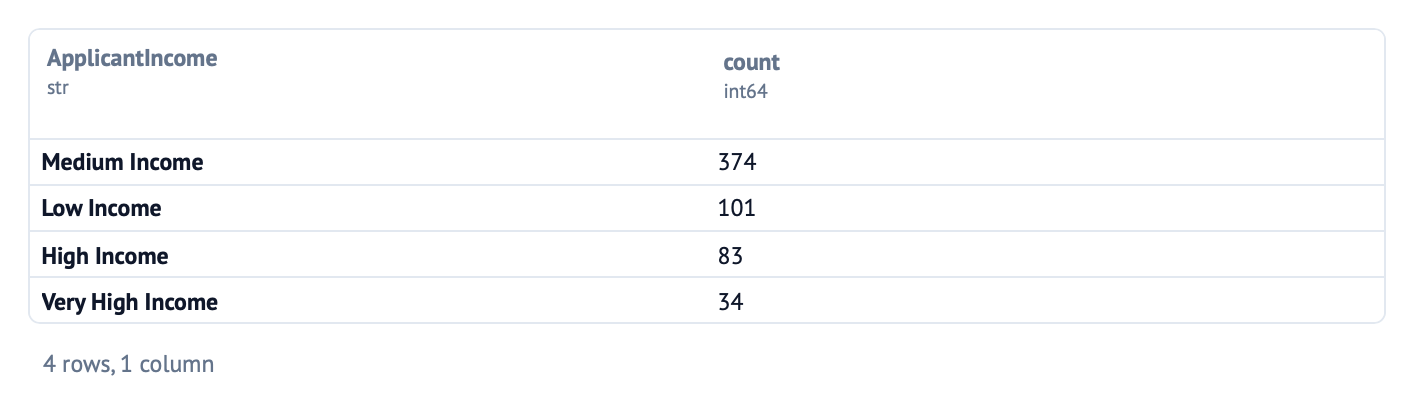

In [ ]:
# Create a function to perfrom the binning.
def bucketize_income (monthly_income):
    income = monthly_income * 12
    if income <= 30000:
        return 'Low Income'
    elif income > 30000 and income <= 75000:
        return 'Medium Income'
    elif income > 75000 and income <= 150000:
        return 'High Income'
    elif income > 150000:
        return 'Very High Income'

df_cleaned['ApplicantIncome'] = df_cleaned['ApplicantIncome'].apply(bucketize_income)
df_cleaned['ApplicantIncome'].value_counts()

### **7.2 Check for outliers in CoApplicantIncome Feature**

#### Plot the data using a regular box plot to understand the outliers.

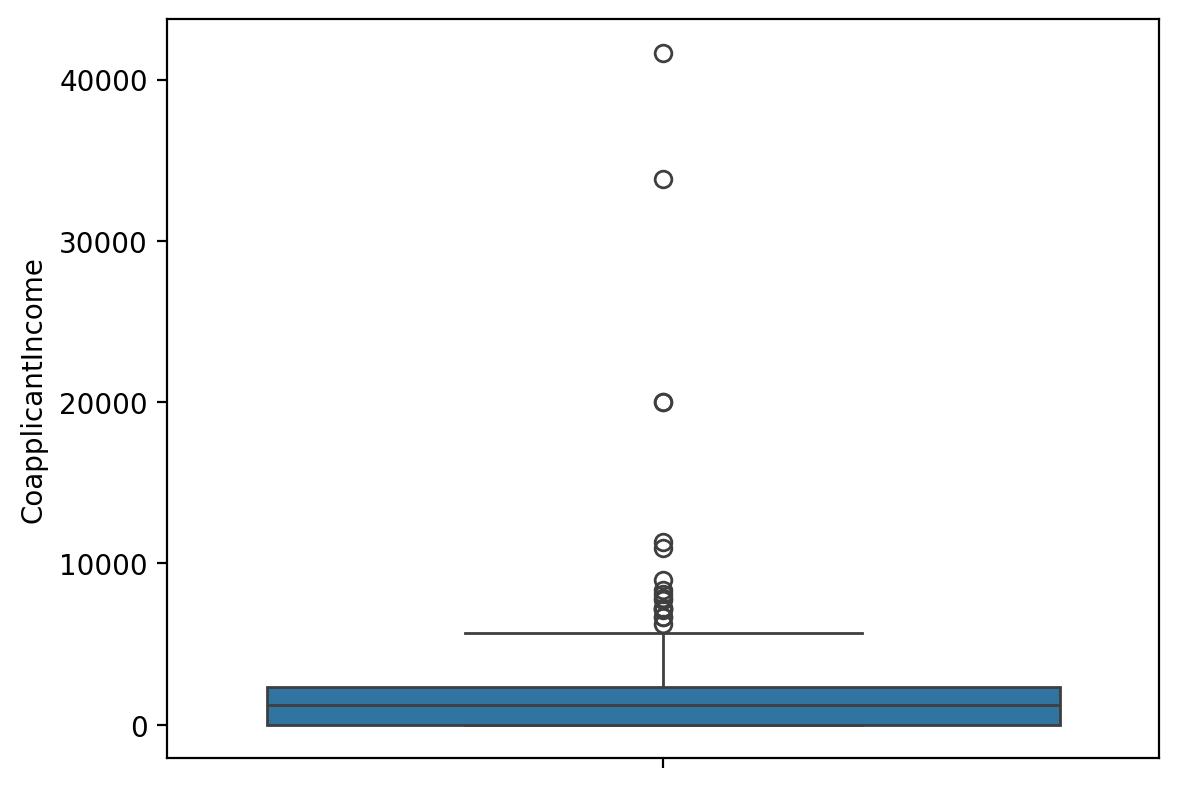

In [ ]:
sns.boxplot(data=df_cleaned, y = 'CoapplicantIncome')
plt.show()

#### Understand the distribution of outliers using histplot.

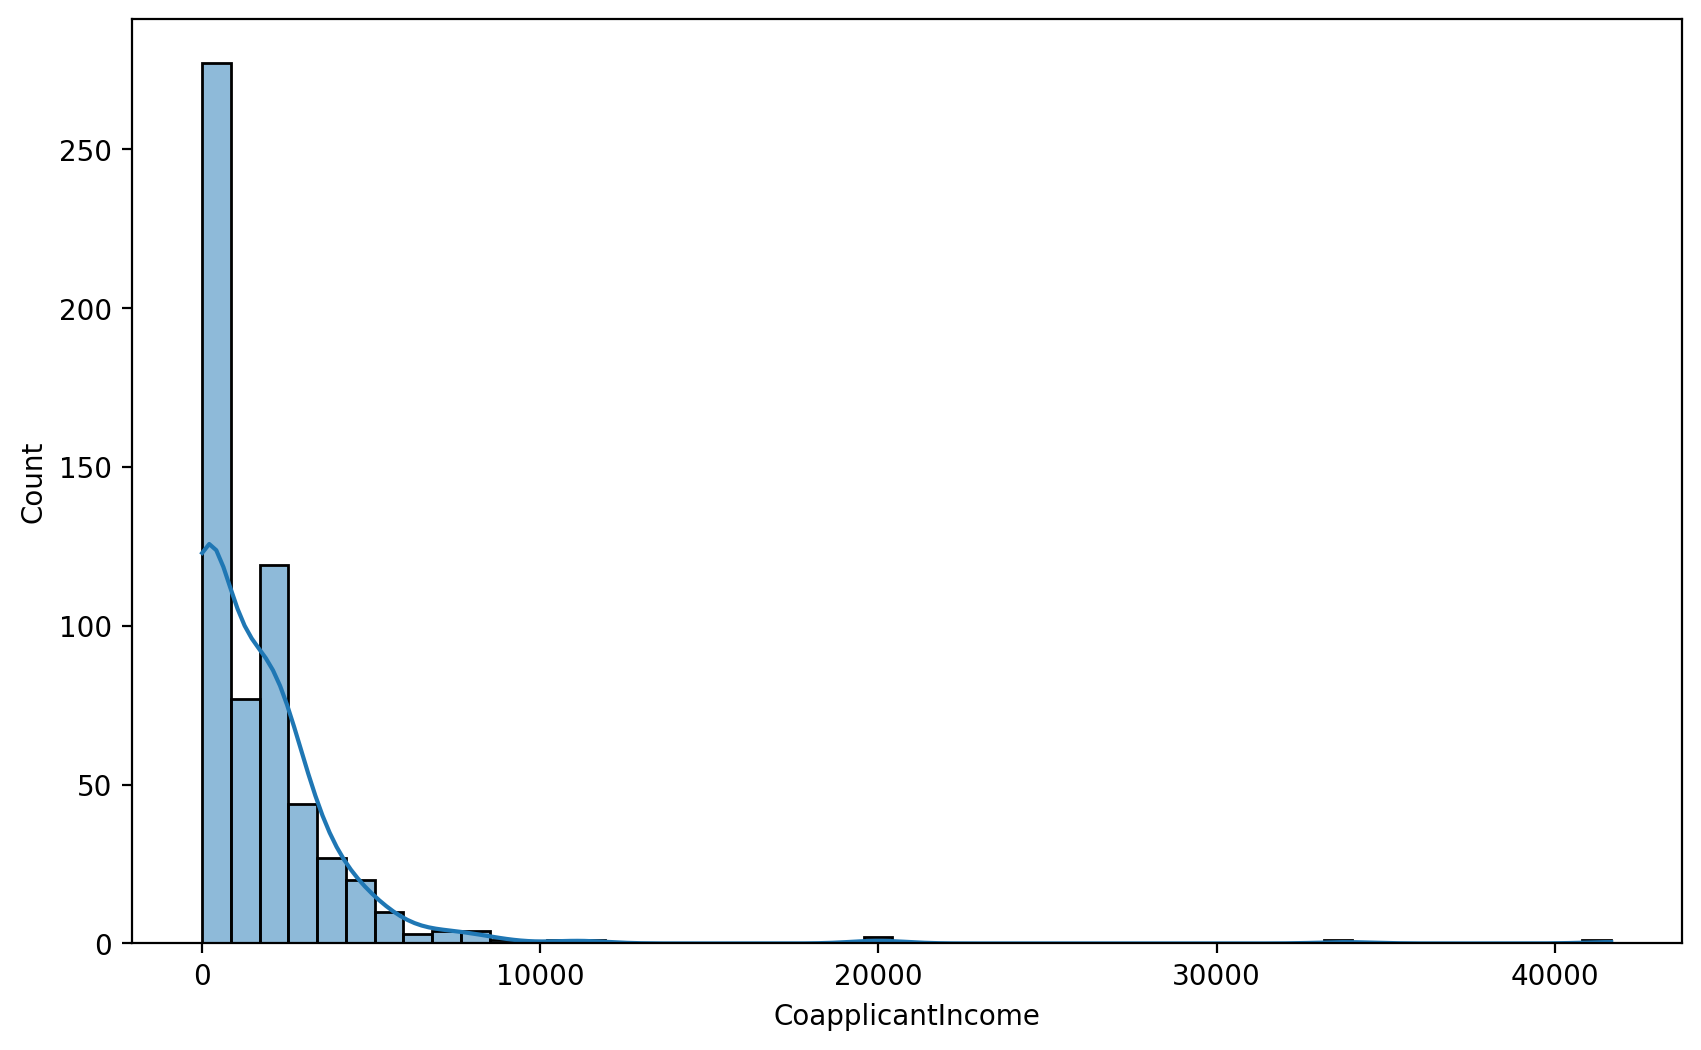

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df_cleaned.CoapplicantIncome, kde=True)
plt.show()

In [ ]:
## Run the detection
lb_caincome, ub_caincome, iqr_outliers_caincome = detect_iqr(df_cleaned, 'CoapplicantIncome')


--- IQR Method for CoapplicantIncome ---
Lower Bound: -3468.00
Upper Bound: 5780.00
Number of Outliers Detected: 18


In [ ]:
print(f'Number of outliers below lower bound: {iqr_outliers_caincome[iqr_outliers_caincome.CoapplicantIncome < lb_caincome].shape[0]}')
print(f'Number of outliers above upper bound: {iqr_outliers_caincome[iqr_outliers_caincome.CoapplicantIncome > ub_caincome].shape[0]}')

Number of outliers below lower bound: 0
Number of outliers above upper bound: 18


### The Co Applicant Income data is extremely right sqewed and if we use linear models, the outliers could impact the coefficents. Apart from this, the relationship between income and probability to default is not linear - it is step-wise. Hence we will discretize the Applicant Income feature.

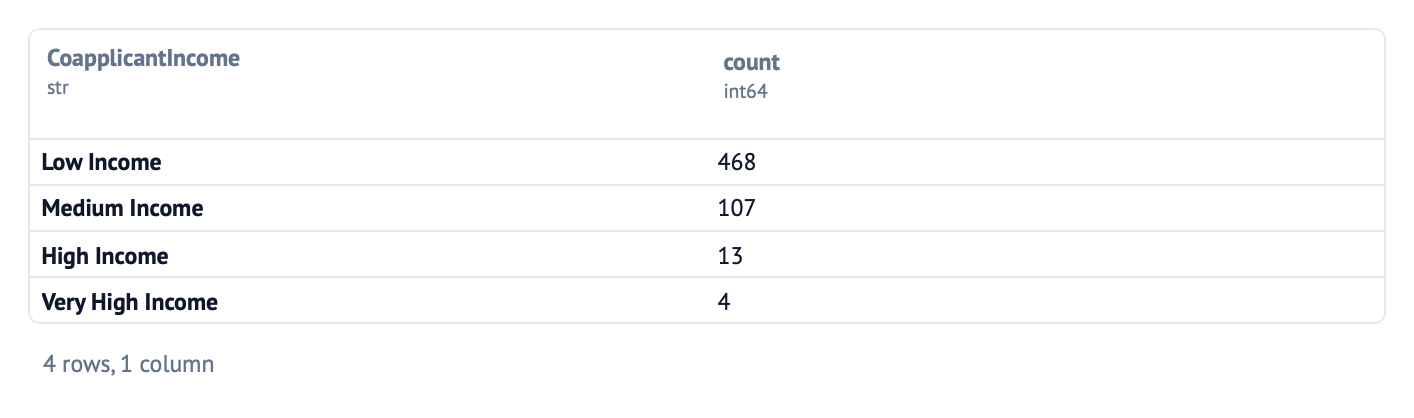

In [ ]:
df_cleaned['CoapplicantIncome'] = df_cleaned['CoapplicantIncome'].apply(bucketize_income)
df_cleaned['CoapplicantIncome'].value_counts()

### **7.3 Check for outliers in Loan Amount Feature**

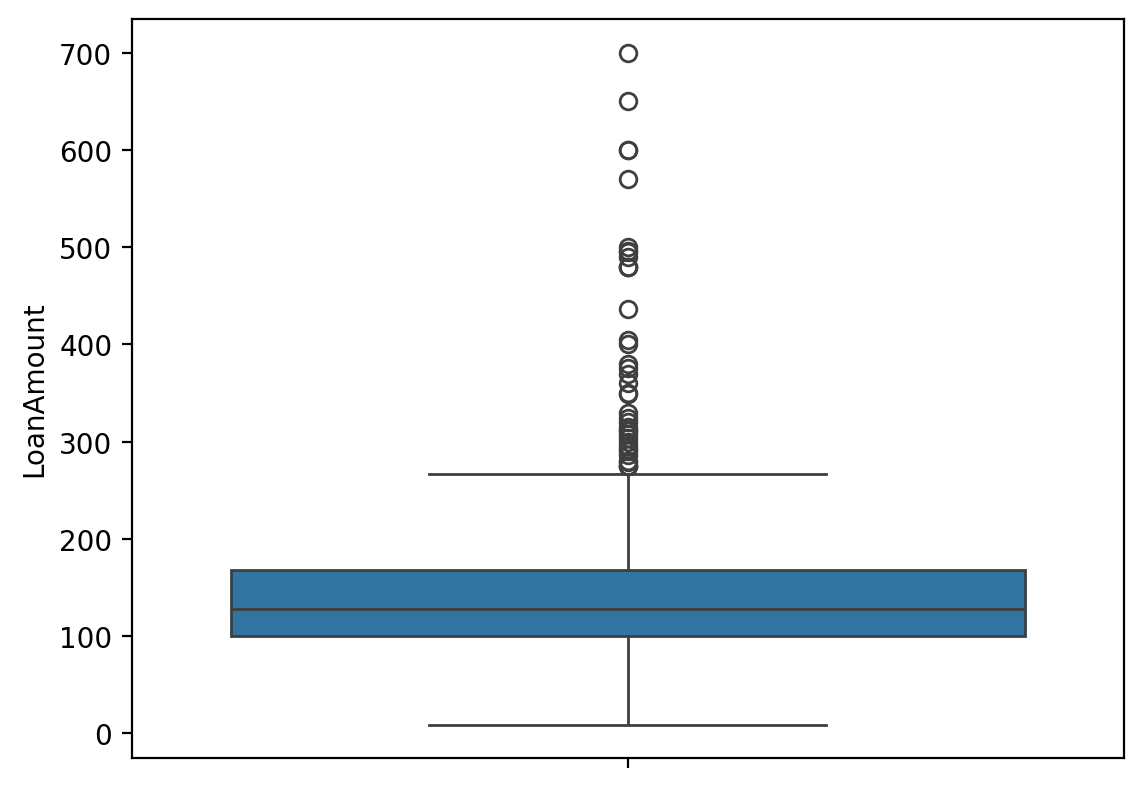

In [ ]:
sns.boxplot(data=df_cleaned, y = 'LoanAmount')
plt.show()

#### Understand the distribution of outliers using histplot.

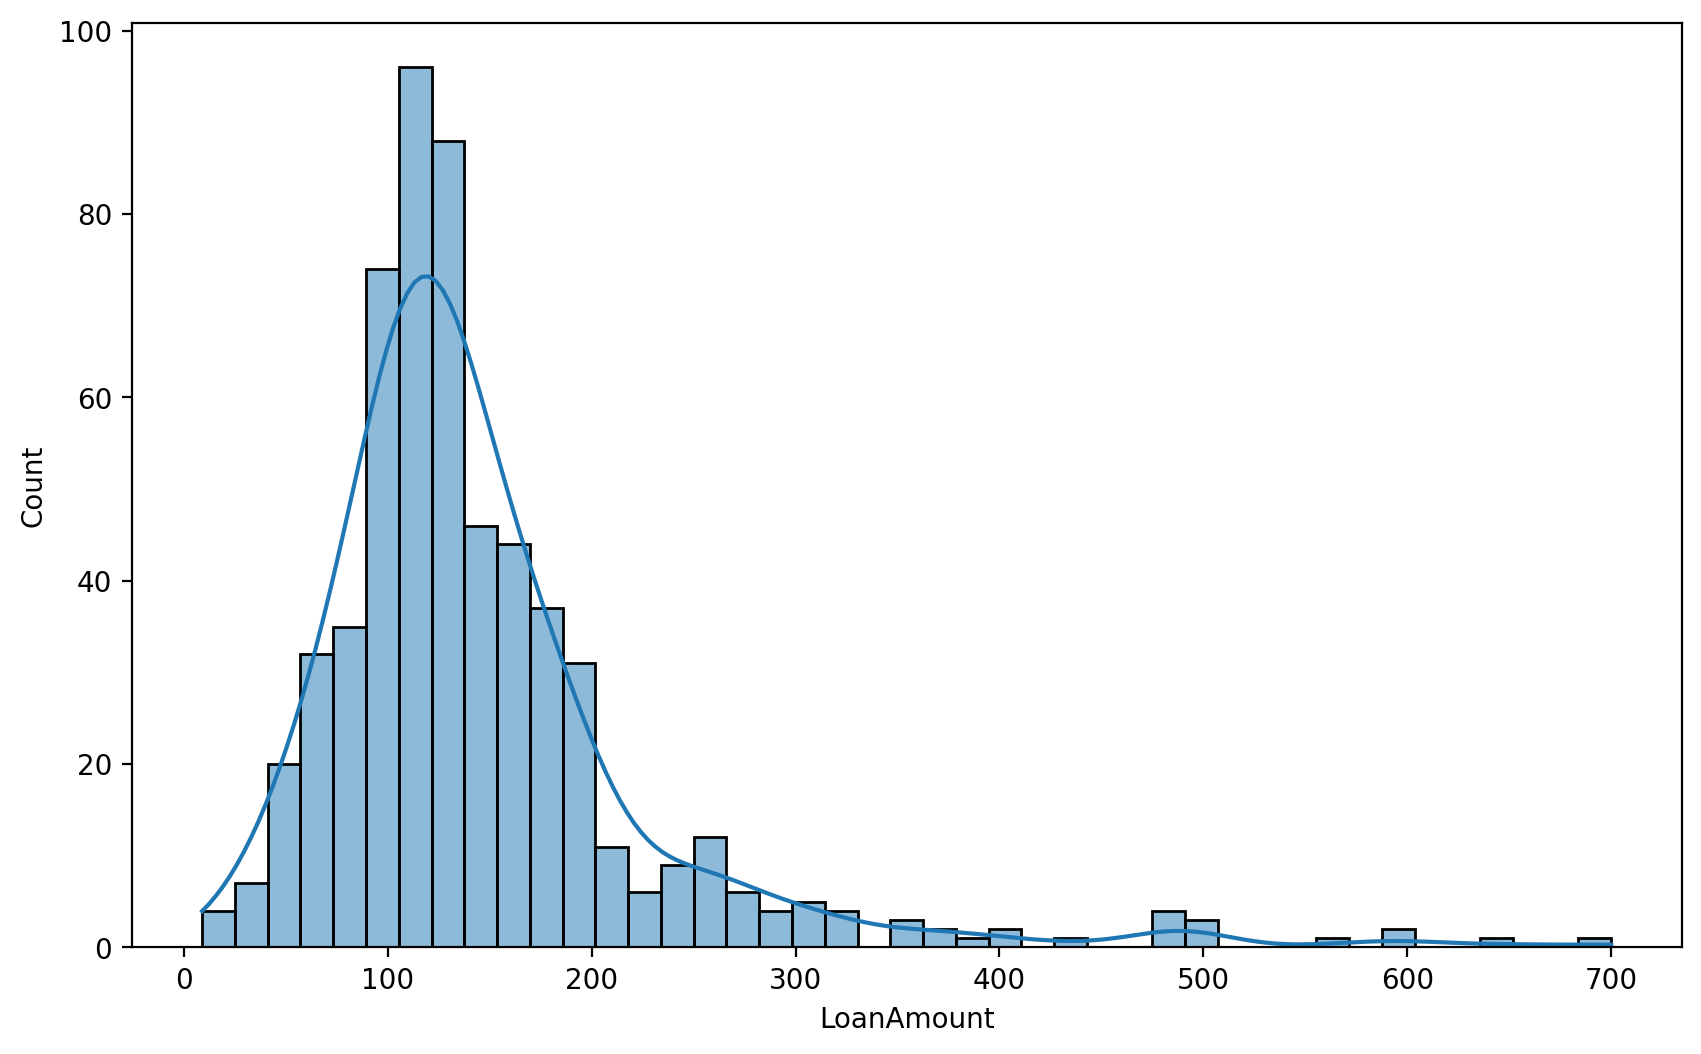

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df_cleaned.LoanAmount, kde=True)
plt.show()

In [ ]:
## Run the detection
lb_la, ub_la, iqr_outliers_la = detect_iqr(df_cleaned, 'LoanAmount')


--- IQR Method for LoanAmount ---
Lower Bound: -2.00
Upper Bound: 270.00
Number of Outliers Detected: 39


In [ ]:
print(f'Number of outliers below lower bound: {iqr_outliers_la[iqr_outliers_la.LoanAmount < lb_la].shape[0]}')
print(f'Number of outliers above upper bound: {iqr_outliers_la[iqr_outliers_la.LoanAmount > ub_la].shape[0]}')

Number of outliers below lower bound: 0
Number of outliers above upper bound: 39


### We will do a quantile binning for the loan amount. But we will perfrom quantile billing onlu after we split the data to avoid data leakage.

### **7.4 Check for outliers in Loan Amount Term Feature**

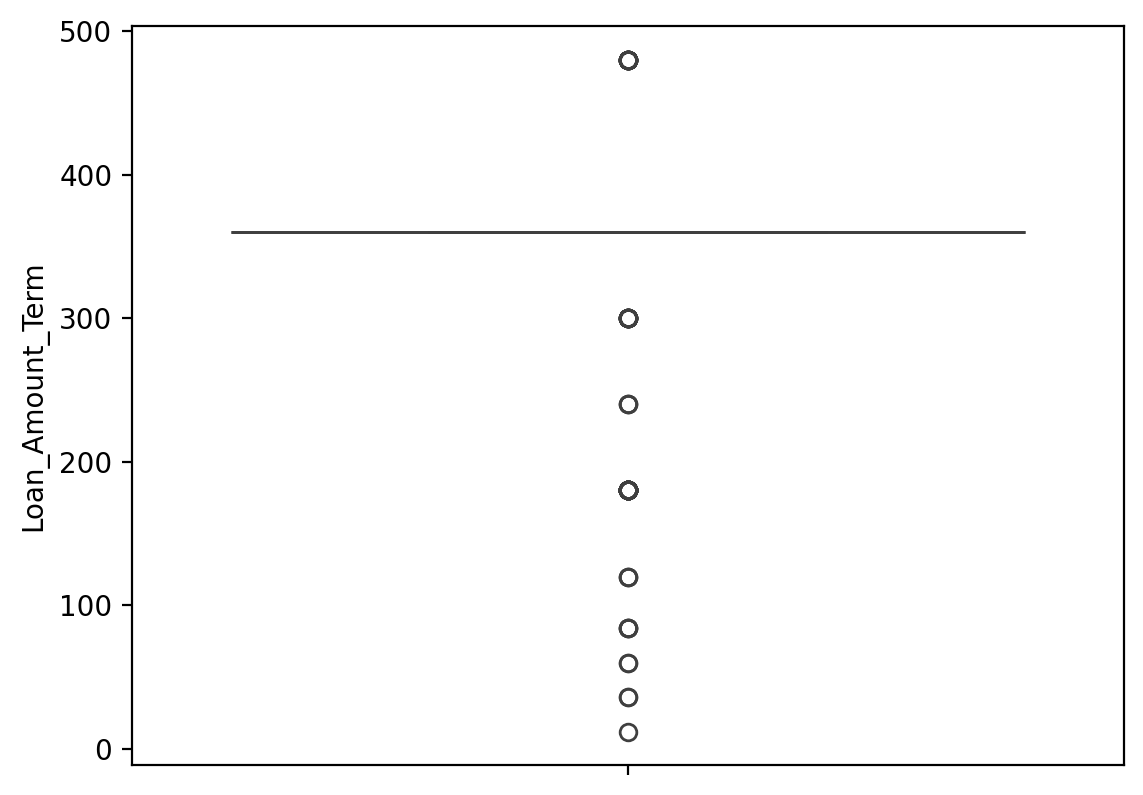

In [ ]:
sns.boxplot(data=df_cleaned, y = 'Loan_Amount_Term')
plt.show()

#### Understand the distribution of outliers using histplot.

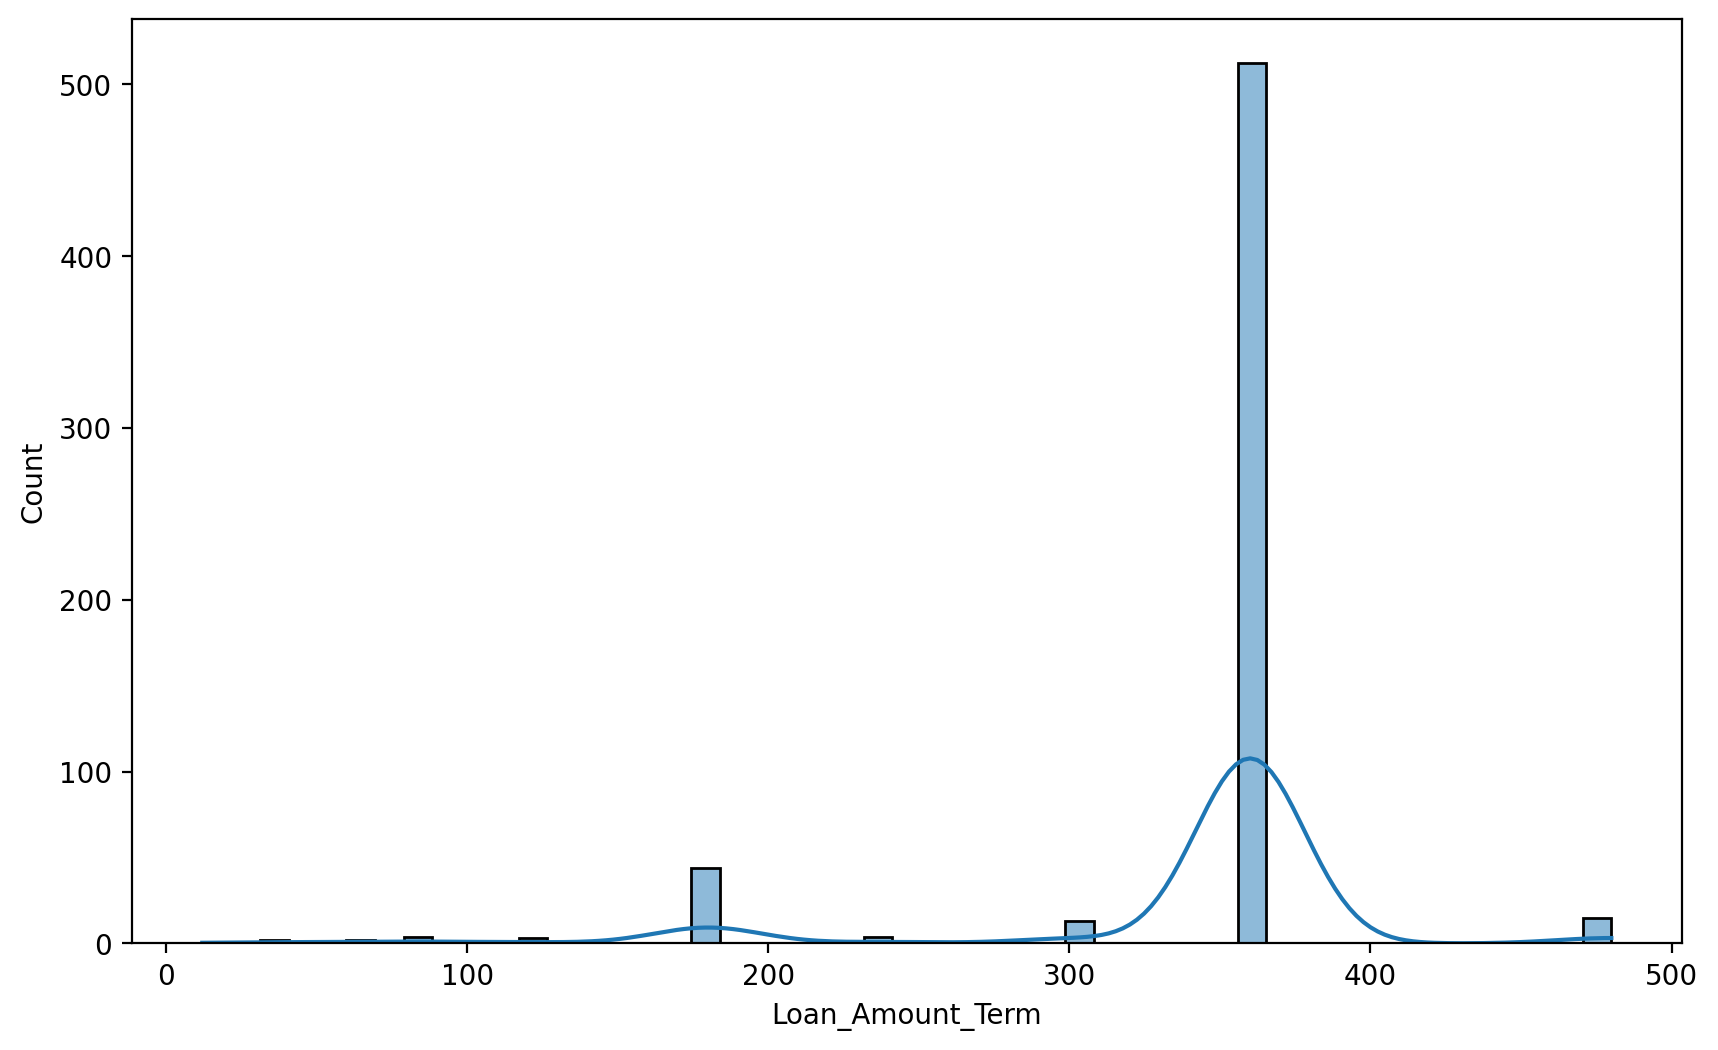

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df.Loan_Amount_Term, kde=True)
plt.show()

#### The data looks descrete and hence we can use the time based bucketing to group the loan terms into standard buckets. <br>
0-2 Years: Short Term <br>
2-5 Years: Medium Term <br>
5-10 Years: Long Term <br>
greater than 10 Years: Very Long Term <br>

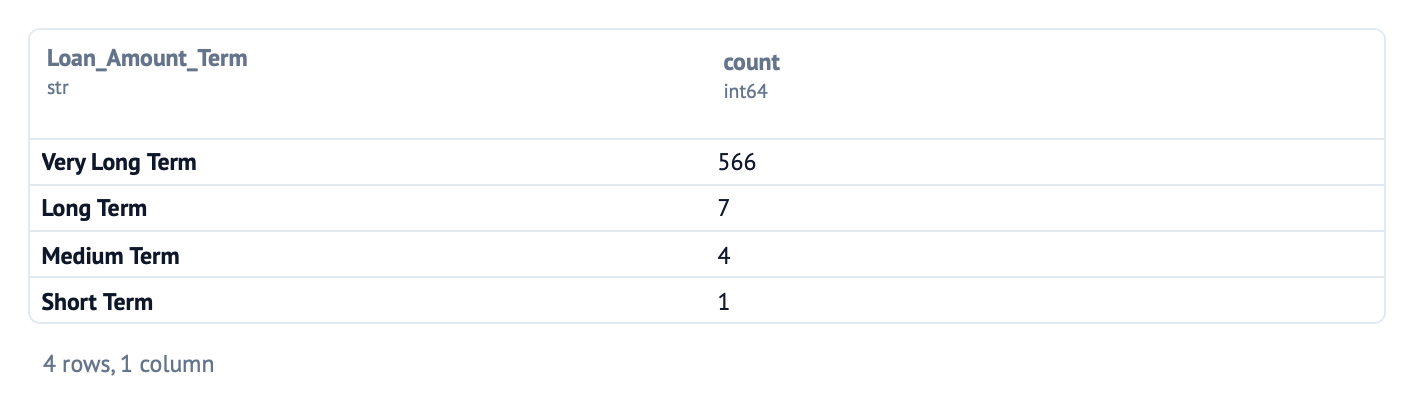

In [ ]:
# Create a function to perfrom the binning.
def bucket_loan_term (loan_term):
    if loan_term <= 24:
        return 'Short Term'
    elif loan_term > 24 and loan_term <= 60:
        return 'Medium Term'
    elif loan_term > 60 and loan_term <= 120:
        return 'Long Term'
    elif loan_term > 120:
        return 'Very Long Term'

df_cleaned['Loan_Amount_Term'] = df_cleaned['Loan_Amount_Term'].apply(bucket_loan_term)
df_cleaned['Loan_Amount_Term'].value_counts()

### **7.5 Check for outliers in Credit History Feature**

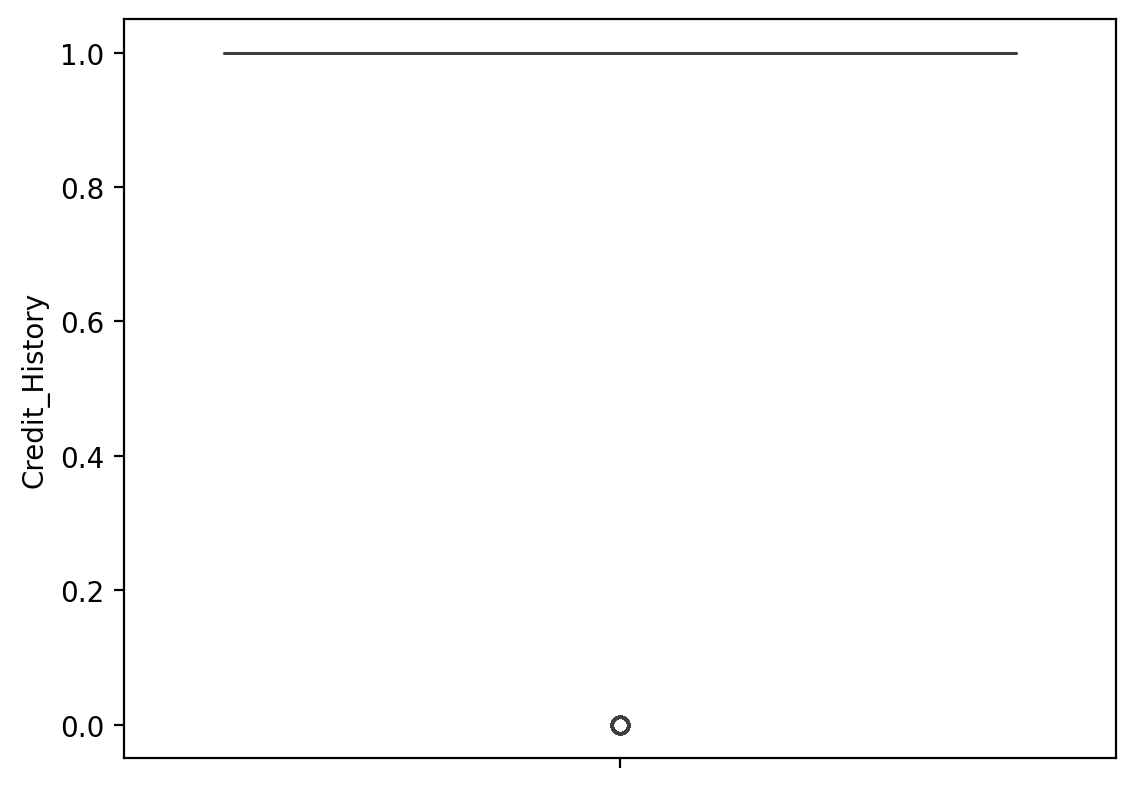

In [ ]:
sns.boxplot(data=df_cleaned, y = 'Credit_History')
plt.show()

#### We do not see any outliers for this feature.

In [ ]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 592 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            592 non-null    str    
 1   Gender             579 non-null    str    
 2   Married            592 non-null    str    
 3   Dependents         592 non-null    object 
 4   Education          592 non-null    str    
 5   Self_Employed      592 non-null    str    
 6   ApplicantIncome    592 non-null    str    
 7   CoapplicantIncome  592 non-null    str    
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   578 non-null    str    
 10  Credit_History     592 non-null    float64
 11  Property_Area      592 non-null    str    
 12  Loan_Status        592 non-null    str    
dtypes: float64(2), object(1), str(10)
memory usage: 105.8+ KB


## 7. EDA for the rest of the features

### 7.1 Inference for Education

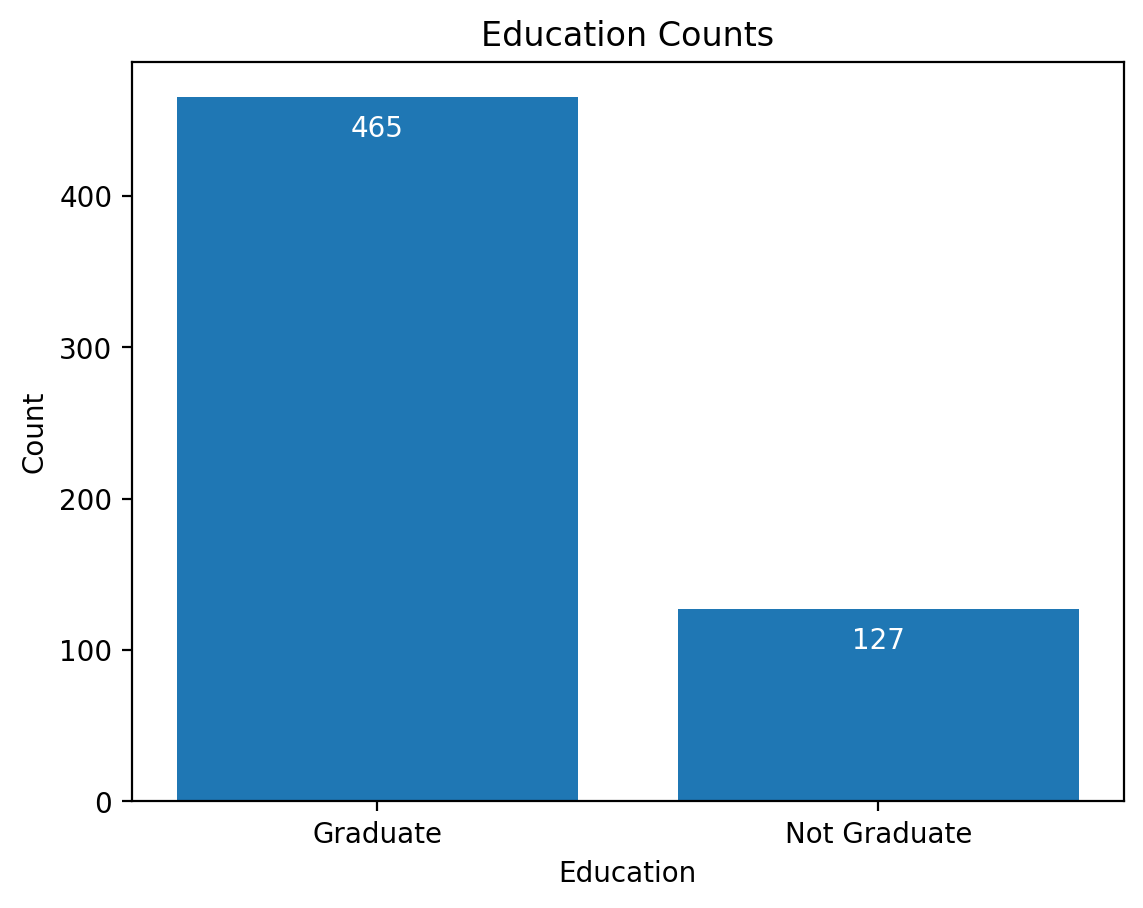

In [ ]:
df_ed_summ = df_cleaned.Education.value_counts().reset_index()
bars_ed = plt.bar(df_ed_summ['Education'], df_ed_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_ed in bars_ed:
    height_ed = bar_ed.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_ed.get_x() + bar_ed.get_width() / 2, # X position (center of the bar)
        height_ed - 30,                       # Y position (slightly above the bar height)
        f'{int(height_ed)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white' )       # Vertical alignment: bottom

plt.title('Education Counts')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()

### 7.2 Inference for Credit_History

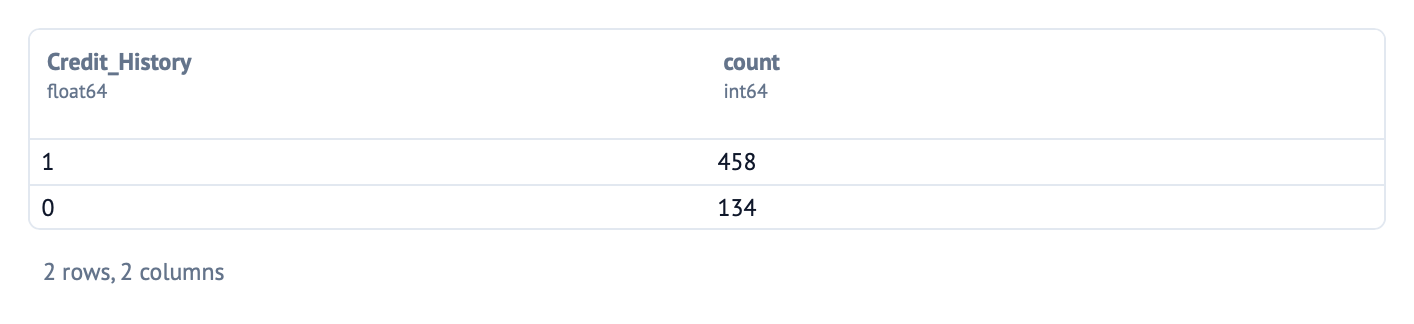

In [ ]:
df_cleaned.Credit_History.value_counts().reset_index()

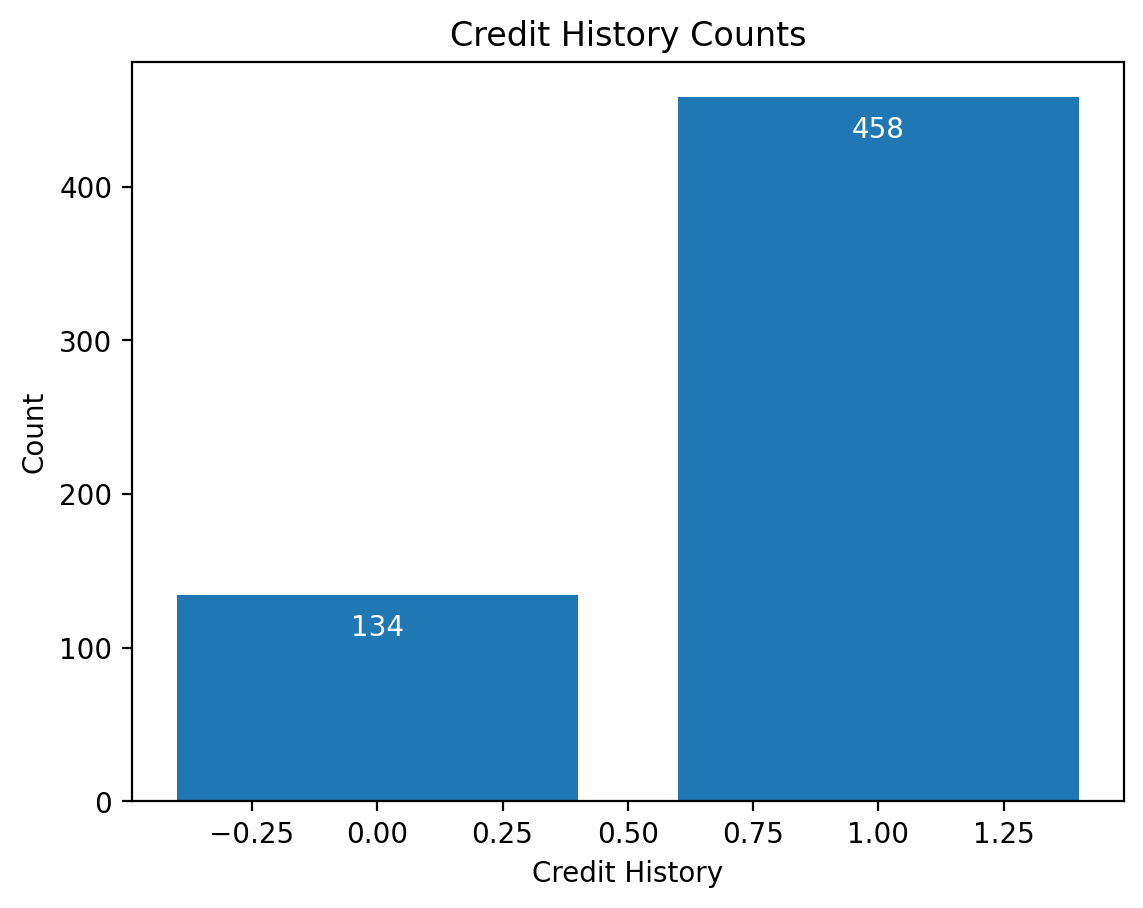

In [ ]:
df_ch0_summ = df_cleaned.Credit_History.value_counts().reset_index()
bars_ch0 = plt.bar(df_ch_summ['Credit_History'], df_ch0_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_ch0 in bars_ch0:
    height_ch0 = bar_ch0.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_ch0.get_x() + bar_ch0.get_width() / 2, # X position (center of the bar)
        height_ch0 - 30,                       # Y position (slightly above the bar height)
        f'{int(height_ch0)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white' )       # Vertical alignment: bottom

plt.title('Credit History Counts')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.show()

### Credit history is a categorical value and hence converting it to string.

In [ ]:
df_cleaned['Credit_History'] = df_cleaned['Credit_History'].astype('category')
def convert_ch(credit_his):
    if credit_his == 1:
        return "Yes"
    else:
        return "No"

df_cleaned['Credit_History'] = df_cleaned['Credit_History'].apply(convert_ch)

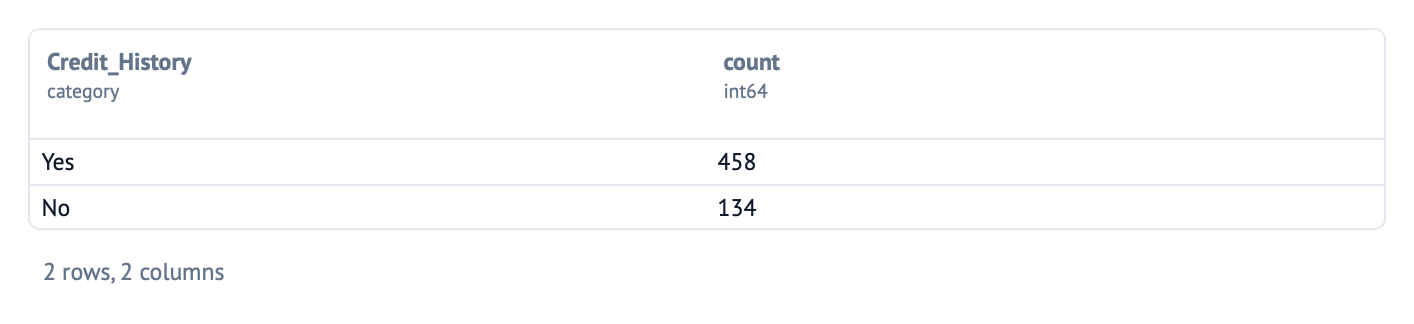

In [ ]:
df_cleaned.Credit_History.value_counts().reset_index()

In [ ]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 592 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Loan_ID            592 non-null    str     
 1   Gender             579 non-null    str     
 2   Married            592 non-null    str     
 3   Dependents         592 non-null    object  
 4   Education          592 non-null    str     
 5   Self_Employed      592 non-null    str     
 6   ApplicantIncome    592 non-null    str     
 7   CoapplicantIncome  592 non-null    str     
 8   LoanAmount         592 non-null    float64 
 9   Loan_Amount_Term   578 non-null    str     
 10  Credit_History     592 non-null    category
 11  Property_Area      592 non-null    str     
 12  Loan_Status        592 non-null    str     
dtypes: category(1), float64(1), object(1), str(10)
memory usage: 101.8+ KB


### 7.3 Inference for Property_Area

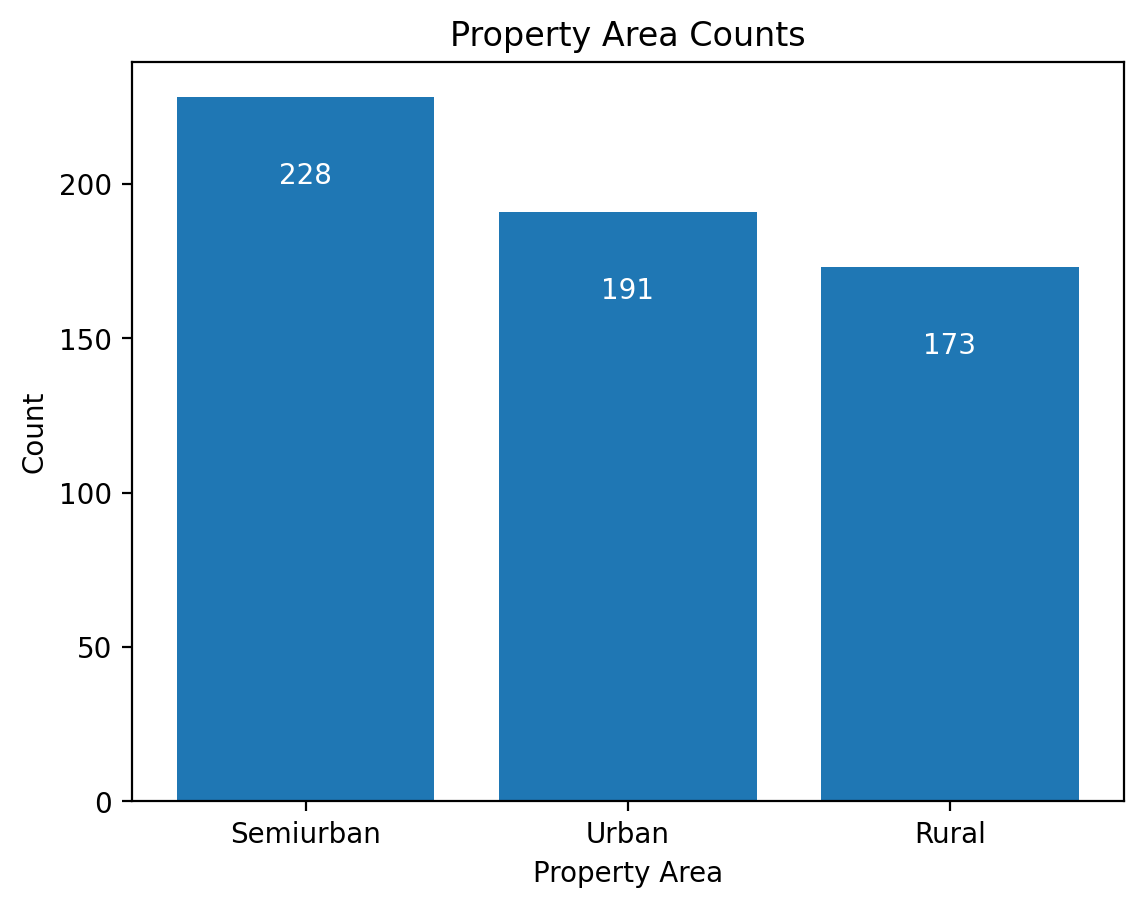

In [ ]:
df_pa_summ = df_cleaned.Property_Area.value_counts().reset_index()
bars_pa = plt.bar(df_pa_summ['Property_Area'], df_pa_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_pa in bars_pa:
    height_pa = bar_pa.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_pa.get_x() + bar_pa.get_width() / 2, # X position (center of the bar)
        height_pa - 30,                       # Y position (slightly above the bar height)
        f'{int(height_pa)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white' )       # Vertical alignment: bottom

plt.title('Property Area Counts')
plt.xlabel('Property Area')
plt.ylabel('Count')
plt.show()

### 7.4 Inference for Loan_Status

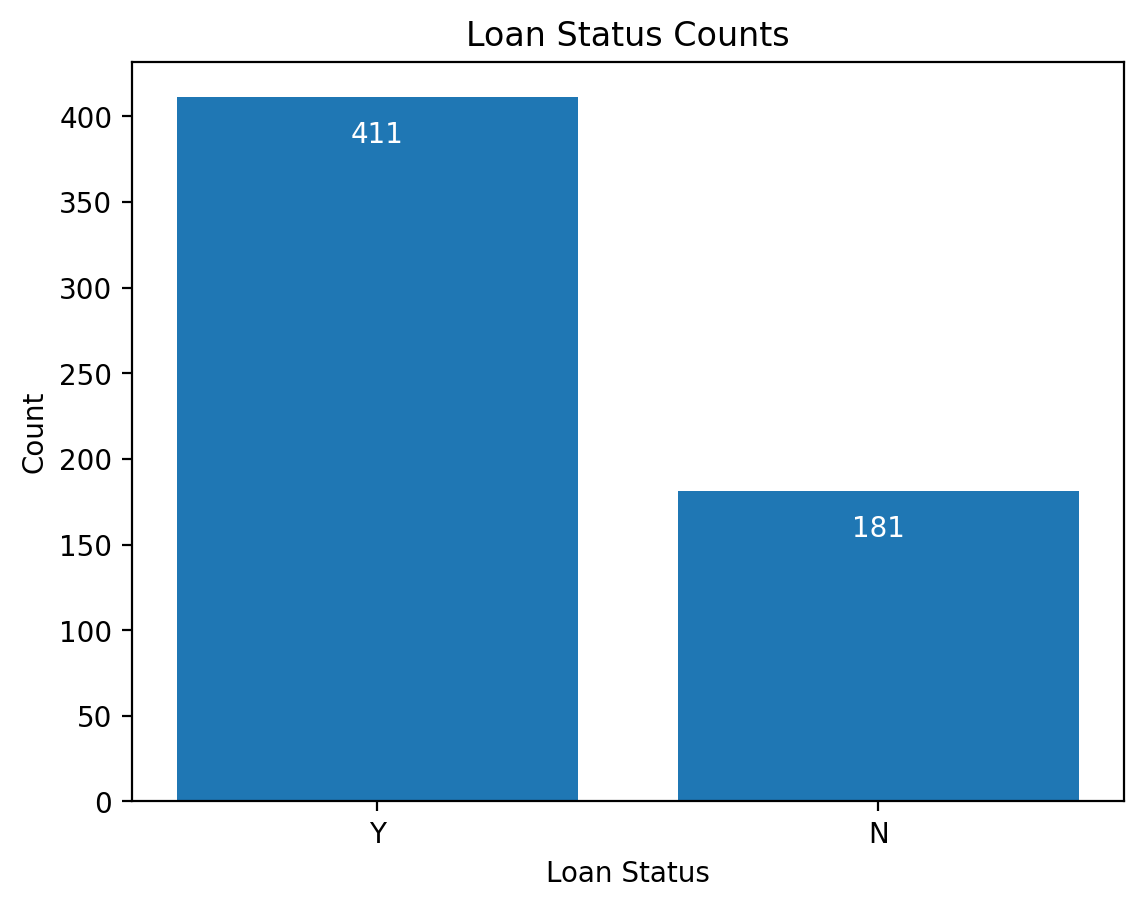

In [ ]:
df_ls_summ = df_cleaned.Loan_Status.value_counts().reset_index()
bars_ls = plt.bar(df_ls_summ['Loan_Status'], df_ls_summ['count'])

# --- Adding Labels (Annotations) to each bar ---
for bar_ls in bars_ls:
    height_ls = bar_ls.get_height()
    # Add the text label above the bar, slightly offset from the top edge
    plt.text(
        bar_ls.get_x() + bar_ls.get_width() / 2, # X position (center of the bar)
        height_ls - 30,                       # Y position (slightly above the bar height)
        f'{int(height_ls)}',                  # The text to display (the count)
        ha='center',                       # Horizontal alignment: center
        va='bottom',color = 'white' )       # Vertical alignment: bottom

plt.title('Loan Status Counts')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

### Convert the loan status to numeric/binary

In [ ]:
def convert_loanstatus(status):
    if status == "Y":
        return 1
    elif status == "N":
        return 0
df_cleaned['Loan_Status'] = df_cleaned['Loan_Status'].apply(convert_loanstatus)

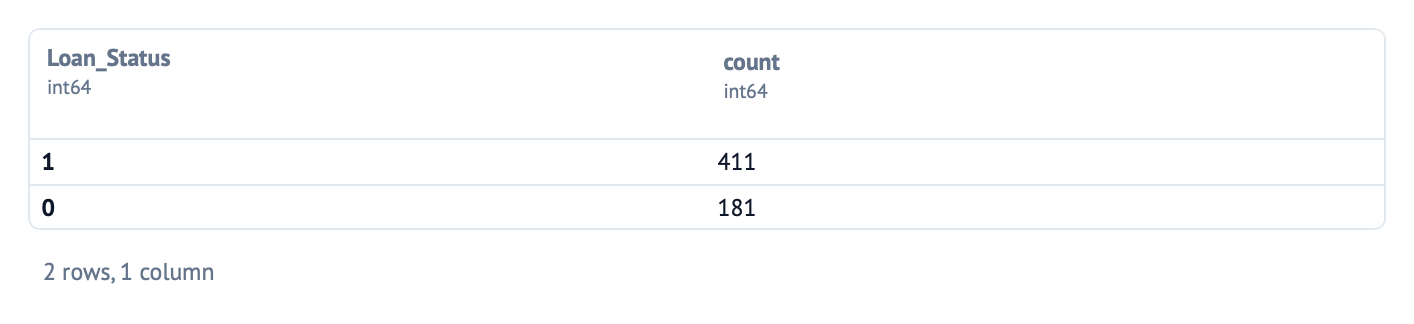

In [ ]:
df_cleaned.Loan_Status.value_counts()

## 8. Save the data into an intermediate file

In [ ]:
print(f'Saving the data in:{output_path}')

Saving the data in:/data/interim/loan_data_interim.csv


In [ ]:
# Save the cleaned dataframe into a csv file. 
df_cleaned.to_csv("/Users/ananddivakaran/Documents/Anand/MDS/loan_app/data/interim/loan_data_interim.csv", index=False, header=True)
# Stop the Spark Session when done
spark.stop()